# Task 2 – Sức khỏe tài chính của khách hàng ITB

Notebook này làm toàn bộ phần phân tích cho Task 2, từ lúc mở dữ liệu đến lúc có đủ số liệu và biểu đồ cho slide 9–12. Mỗi con số được nhắc tới trong phần chữ đều được tính ra ngay ở ô code phía trên nó, để ai đọc cũng tự kiểm tra lại được.

Đề hỏi 4 thứ: điểm sức khỏe phân bố thế nào, điểm thấp gắn với những yếu tố gì, khác biệt theo nghề – tuổi – tỉnh ra sao, và nhóm khách nào căng thẳng về tiền nhưng vẫn dùng thẻ nhiều. Thay vì trả lời từng câu tách rời, notebook đi theo một mạch: hiểu điểm được tạo ra từ đâu, xem căng thẳng xảy ra thế nào, rồi mới hỏi đó là ai. Câu trả lời của phần trước thường là lý do để đặt câu hỏi ở phần sau.

- **Phần 0.** Làm quen với dữ liệu và chuẩn bị bảng
- **Phần 1.** Điểm sức khỏe được tạo ra từ đâu
- **Phần 2.** Điểm phân bố thế nào (slide 9)
- **Phần 3.** Căng thẳng kéo dài bao lâu, xảy ra khi nào, do chi vào gì (slide 10)
- **Phần 4.** Căng thẳng rơi vào nhóm khách nào: theo nghề, tuổi, tỉnh (slide 11)
- **Phần 5.** Nhóm căng thẳng nhưng tương tác cao (slide 12)
- **Phần 6.** Tóm tắt và các tín hiệu chuyển sang Task 5

Dữ liệu gốc đặt trong thư mục `data/` và không bị sửa. Biểu đồ lưu trong `charts/`, bảng số và dữ liệu đã xử lý lưu trong `outputs/`. Chữ trên biểu đồ viết bằng tiếng Anh để đưa thẳng lên slide.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from IPython.display import display

DATA = Path('../data')
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
CH = Path('charts'); CH.mkdir(exist_ok=True)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Màu dùng chung cho biểu đồ: đỏ cho tháng/khách căng thẳng, xám cho phần còn lại
RED, BLUE, GRAY, LGRAY = '#e34948', '#2a78d6', '#9b9a94', '#d9d8d3'
INK, INK2 = '#0b0b0b', '#52514e'
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.edgecolor': LGRAY, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'grid.color': '#ecebe7', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': INK2, 'ytick.color': INK2, 'legend.frameon': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

def save(fig, name):
    fig.savefig(CH / f'{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

BANDS = ['<40', '40–60', '60–80', '≥80']

# Tên cột dễ đọc khi hiển thị bảng và khi lưu file số liệu
LBL = {
    'so_nghe': 'số nghề', 'vi_du': 'ví dụ 3 nghề', 'so_khach_du_nam': 'số khách đủ năm',
    'so_thang': 'số tháng', 'pct_thang_sau_van_duoi_40': '% trường hợp tháng sau có điểm dưới 40',
    'diem_trung_binh_thang_sau': 'điểm trung bình tháng sau',
    'so_thang_duoi_40': 'số lần dưới 40', 'diem_trung_binh': 'điểm trung bình',
    'pct_khach_chi_vuot_thu_nhap': '% khách chi vượt thu nhập', 'trung_vi_chi_tren_thu_nhap': 'chi / thu nhập (trung vị)',
    'pct_thang_co_giao_dich_lon': '% số tháng có giao dịch ≥20% thu nhập tháng',
    'trung_vi_lon_nhat_tren_thu_nhap': 'giao dịch lớn nhất bằng bao nhiêu % thu nhập tháng (trung vị)',
    'trung_vi_pct_chi_tu_giao_dich_lon': '% chi tiêu đến từ giao dịch lớn (trung vị)',
    'so_khach': 'số khách', 'diem_tb': 'điểm trung bình', 'pct_tung_duoi_40': '% khách từng có tháng dưới 40',
    'chi_tren_thu_nhap': 'chi / thu nhập', 'han_muc_da_dung': 'hạn mức đã dùng', 'ty_le_thiet_yeu': 'tỷ lệ chi thiết yếu',
    'so_thang_chi_vuot': 'số tháng chi vượt thu nhập', 'ci95': 'khoảng tin cậy 95% (±)',
    'consumer_id': 'mã khách', 'n_months': 'số tháng có dữ liệu', 'age': 'tuổi', 'gender': 'giới tính',
    'occupation': 'nghề', 'occupation_group': 'lĩnh vực nghề', 'province': 'tỉnh',
    'health_avg': 'điểm sức khỏe trung bình năm', 'health_min': 'điểm của tháng thấp nhất trong năm',
    'months_below_40': 'số tháng dưới 40', 'engagement_avg': 'điểm tương tác trung bình năm',
    'spend_to_income': 'chi / thu nhập', 'credit_utilization': 'hạn mức đã dùng',
    'spending_volatility': 'mức chi thất thường', 'essential_ratio': 'tỷ lệ chi thiết yếu',
    'online_ratio': 'tỷ lệ chi online', 'txn_per_month': 'số giao dịch mỗi tháng',
    'months_overspend': 'số tháng chi vượt thu nhập', 'full_year': 'đủ 12 tháng', 'age_band': 'nhóm tuổi',
    'travel_share': '% chi cho du lịch', 'online_shopping_share': '% chi cho mua sắm online',
    'pct_tung_co_giao_dich_lon': '% khách từng có giao dịch ≥20% thu nhập tháng', 'pct_nu': '% nữ',
}
LBL.update({'band': 'mức điểm của tháng', 'month': 'tháng', 'spending_category': 'nhóm chi tiêu',
            'khung_gio': 'khung giờ', 'transaction_day_of_week': 'ngày trong tuần', 'next_band': 'mức tháng sau'})
def vn(df):
    out = df.rename(columns=LBL, index=LBL)
    out.index.name = LBL.get(df.index.name, df.index.name)
    if out.columns.name is not None:
        out.columns.name = LBL.get(out.columns.name, out.columns.name)
    return out
def to_band(s):
    return pd.cut(s, [-np.inf, 40, 60, 80, np.inf], right=False, labels=BANDS)

## Phần 0 – Làm quen với dữ liệu

Điểm sức khỏe tài chính chỉ có trong file tổng kết theo tháng, nên Task 2 dựa chủ yếu vào file này. Trước khi tính gì, mở ra xem vài dòng đầu để biết mỗi dòng đang ghi lại điều gì.

In [2]:
cm = pd.read_csv(DATA / 'consumer_financial_health_engagement_2025.csv')
cm['analysis_month'] = pd.to_datetime(cm['analysis_month'])
cm['month'] = cm['analysis_month'].dt.month
print('Kích thước:', cm.shape)
cm.head(3).T

Kích thước: (10992, 31)


,0,1,2
consumer_id,KH00100010,KH00100010,KH00100010
analysis_month,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00
age,27,27,27
gender,Nam,Nam,Nam
occupation,Kỹ sư sản xuất,Kỹ sư sản xuất,Kỹ sư sản xuất
province_city,Đồng Nai,Đồng Nai,Đồng Nai
monthly_income_vnd,1003930000,961510000,916740000
credit_limit_vnd,3780600000,3780600000,3780600000
opening_balance_vnd,501965000,1065133000,1627173000
ending_balance_vnd,1065133000,1627173000,2029964000


Mỗi dòng là một khách trong một tháng: thu nhập, hạn mức, tổng chi, các tỷ lệ chi tiêu, và hai điểm số của tháng đó. Nếu đúng vậy thì cặp mã khách và tháng không được lặp lại. Kiểm tra điều đó, đồng thời xem mỗi khách có bao nhiêu tháng dữ liệu và cột nào bị trống.

In [3]:
print('Số cặp khách–tháng bị trùng:', cm.duplicated(['consumer_id', 'analysis_month']).sum())
print('Các cột có ô trống:', cm.isna().sum()[lambda s: s > 0].to_dict())

cm['n_months'] = cm.groupby('consumer_id')['consumer_id'].transform('size')
cm['full_year'] = cm['n_months'] == 12
(cm.drop_duplicates('consumer_id')['n_months'].value_counts().sort_index()
   .rename_axis('số tháng có dữ liệu').rename('số khách').to_frame())

Số cặp khách–tháng bị trùng: 0
Các cột có ô trống: {'next_month_low_health_flag': 999}


,số khách
số tháng có dữ liệu,
1,86
2,5
12,908


Không có dòng trùng. Cột `next_month_low_health_flag` trống đúng 999 ô, tức mỗi khách trống một ô ở tháng cuối cùng của họ, vì không có tháng sau để đánh dấu.

Có 908 khách đủ 12 tháng, còn 91 khách chỉ xuất hiện 1 hoặc 2 tháng. Câu hỏi là có nên so 91 khách này chung với những người còn lại không. So median của các tháng giữa hai nhóm:

In [4]:
cm.groupby('full_year')[['transaction_count', 'active_transaction_days', 'category_diversity',
                         'engagement_score', 'financial_health_score']].median() \
  .rename(index={True: '908 khách đủ năm', False: '91 khách chỉ có 1–2 tháng'})

,transaction_count,active_transaction_days,category_diversity,engagement_score,financial_health_score
full_year,,,,,
91 khách chỉ có 1–2 tháng,10.00,2.00,5.00,49.95,65.05
908 khách đủ năm,151.00,30.00,14.00,78.10,67.70


Ở 91 khách này, median mỗi tháng chỉ là 10 giao dịch trong 2 ngày, trong khi khách đủ năm có khoảng 150 giao dịch rải khắp 30 ngày. Họ giống người ghé qua hơn là khách thường xuyên. Điểm trung bình năm của họ thực chất chỉ là điểm của 1–2 tháng, không so được với người có 12 tháng. Vì vậy, **mọi phép so sánh giữa các khách trong notebook này chỉ dùng 908 khách đủ năm**.

Tiếp theo, chia điểm sức khỏe thành 4 mức theo đúng mốc đề dùng ở Task 1: dưới 40, 40–60, 60–80 và từ 80. Dữ liệu có sẵn cột nhóm sức khỏe, nên đặt cạnh nhau để chắc chắn mốc của mình khớp với cách dữ liệu đã chia.

In [5]:
cm['band'] = to_band(cm['financial_health_score'])
vn(pd.crosstab(cm['band'], cm['financial_health_segment']))

financial_health_segment,Có dấu hiệu căng thẳng tài chính,Cần theo dõi,Khỏe mạnh,Ổn định
mức điểm của tháng,,,,
<40,95,0,0,0
40–60,0,2457,0,0
60–80,0,0,0,7965
≥80,0,0,475,0


Mỗi mức khớp đúng một nhóm có sẵn, không lệch dòng nào. Từ đây dùng cột `band` cho gọn.

### Nghề nghiệp: có cần gộp không

Đề hỏi khác biệt theo nghề. Trước khi so, xem mỗi nghề có bao nhiêu người.

In [6]:
occ_counts = cm.drop_duplicates('consumer_id')['occupation'].value_counts()
pd.Series({
    'Số nghề khác nhau': len(occ_counts),
    'Số nghề chỉ có 1 người': (occ_counts == 1).sum(),
    'Số nghề có từ 3 người trở xuống': (occ_counts <= 3).sum(),
    'Số người của nghề đông nhất': occ_counts.max(),
}).to_frame('giá trị')

,giá trị
Số nghề khác nhau,396
Số nghề chỉ có 1 người,128
Số nghề có từ 3 người trở xuống,312
Số người của nghề đông nhất,10


396 nghề mà nghề đông nhất chỉ có 10 người, 128 nghề chỉ có đúng 1 người. So nghề với nghề thì mỗi con số chỉ dựa trên vài người, không nói lên được gì. Cách hợp lý là gộp theo lĩnh vực: xếp theo từ khóa trong tên nghề (ví dụ nghề có chữ "Kỹ sư" vào nhóm kỹ thuật), rồi sửa tay những nghề bị xếp nhầm. Mục tiêu là khoảng 10 lĩnh vực, mỗi lĩnh vực ít nhất 30 khách.

In [7]:
OCC_RULES = [
 ('Nông nghiệp và môi trường', ['vật nuôi','chăn nuôi','Chuyên viên làm vườn','tư vấn làm vườn','cây','nông','Nông','lâm nghiệp','Kiểm lâm','thủy sản','môi trường','Môi trường','thổ nhưỡng','chọn giống','sinh thái','bảo tồn thiên nhiên','chất thải','nông trại']),
 ('Công nghệ thông tin', ['Lập trình','phần mềm','công nghệ thông tin','cơ sở dữ liệu','Kỹ sư mạng','phân tích hệ thống','hệ thống thông tin','khoa học dữ liệu','thiết kế web','Giám đốc công nghệ']),
 ('Y tế và chăm sóc sức khỏe', ['Bác sĩ','Dược','Trình dược','Điều dưỡng','trị liệu','Trị liệu','tâm lý','y tế','Y tế','y khoa','lâm sàng','cấp cứu','cứu thương','kính thuốc','đo mắt','chỉnh thị','châm cứu','bàn chân','nắn chỉnh','đông y','vi lượng','thính học','xạ trị','chẩn đoán hình ảnh','sinh lý vận động','dinh dưỡng','truyền thông sức khỏe','Thư ký y khoa','vệ sinh lao động','an toàn lao động']),
 ('Tài chính và pháp lý', ['Kế toán','kế toán','tài chính','Tài chính','ngân hàng','thuế','Thuế','bảo hiểm','bồi thường','giao dịch','Luật sư','pháp chế','pháp lý','Thư ký luật','phân tích rủi ro','phân tích đầu tư','hưu trí','công chứng']),
 ('Giáo dục', ['Giáo viên','Giảng viên','Giáo sư','giáo sư','Thủ thư','hướng nghiệp','giáo dục','Người hướng dẫn học tập','Nhà biên soạn từ điển']),
 ('Khoa học và nghiên cứu', ['Nhà khoa học','khoa học','Nhà địa','địa chất','địa chấn','địa vật lý','địa hóa','Nhà hóa','hóa sinh','di truyền','Nhà hải dương','Nhà vật lý','thủy văn','Nhà khảo cổ','Nhà kinh tế','Nhà luyện kim','Nhà miễn dịch','Nhà dược lý','Nhà độc chất','Nhà nghiên cứu','nghiên cứu','Nhà thống kê','phòng thí nghiệm','phân tích mẫu','Nhà văn khoa học','Nghiên cứu viên']),
 ('Kỹ thuật và xây dựng', ['Kỹ sư','Kiến trúc sư','kiến trúc','xây dựng','công trình','trắc địa','khảo sát','vẽ bản đồ','quy hoạch','Nhà thầu','Kỹ thuật viên','công nghệ dệt may','màu sắc','bảo trì','mỏ đá']),
 ('Truyền thông, nghệ thuật và thiết kế', ['Biên tập','biên tập','Nhà báo','Phóng viên','thiết kế','Họa sĩ','Nghệ sĩ','nghệ thuật','Nhạc sĩ','Vũ công','Đạo diễn','phim','hoạt hình','kỹ xảo','phát thanh','truyền hình','phát sóng','quảng cáo','truyền thông','quan hệ công chúng','trang điểm','Nhà văn','Nghệ nhân','trường quay','bối cảnh','sân khấu','nhà hát','phòng tranh','bảo tàng','phục chế','di sản','di tích','nội dung','Người quay phim','Thông dịch','Người dẫn chương trình','ánh sáng']),
 ('Khu vực công và cộng đồng', ['Cán bộ','Công chức','Cảnh sát','Sĩ quan','Lính cứu hỏa','trại giam','Thanh tra','cộng đồng','cứu trợ','từ thiện','tình nguyện','gây quỹ','chính trị','Chánh văn phòng','công đoàn','xuất nhập cảnh','tình báo','hỗ trợ','quản chế','đất đai']),
 ('Kinh doanh và dịch vụ', ['Giám đốc','giám đốc','Quản lý','Quản trị viên','kinh doanh','Chuyên viên nhân sự','thu mua','bán lẻ','trưng bày','tiếp thị','xúc tiến','Thư ký','thị trường','sự kiện','Người bán sách','du lịch','khách sạn','Phi công','Tiếp viên','Kiểm soát viên không lưu','giao nhận','môi giới','pha chế','Chuyên viên lưu trữ','bất động sản','sản phẩm','vận hành','tư vấn quản lý']),
]
# Những nghề mà từ khóa xếp chưa đúng, sửa tay
OCC_OVERRIDE = {
    'Nhà khoa học lâm sàng miễn dịch di truyền': 'Khoa học và nghiên cứu',
    'Nhà hóa sinh lâm sàng': 'Khoa học và nghiên cứu',
    'Chuyên viên nghiên cứu thị trường': 'Kinh doanh và dịch vụ',
    'Nhà thiết kế dệt may': 'Truyền thông, nghệ thuật và thiết kế',
    'Kỹ sư y sinh': 'Kỹ thuật và xây dựng',
    'Kỹ thuật viên phòng thí nghiệm giảng dạy': 'Giáo dục',
    'Giảng viên công nghệ thông tin': 'Công nghệ thông tin',
}
def occ_group(o):
    if o in OCC_OVERRIDE:
        return OCC_OVERRIDE[o]
    for g, kws in OCC_RULES:
        if any(k in o for k in kws):
            return g
    return 'Unmapped'

occ_map = pd.DataFrame({'occupation': sorted(cm['occupation'].unique())})
occ_map['occupation_group'] = occ_map['occupation'].map(occ_group)
print('Số nghề chưa xếp được:', (occ_map['occupation_group'] == 'Unmapped').sum())
occ_map.to_csv(OUT / 'occupation_groups.csv', index=False, encoding='utf-8-sig')
cm['occupation_group'] = cm['occupation'].map(dict(zip(occ_map.occupation, occ_map.occupation_group)))

# Mỗi lĩnh vực: số nghề, số khách đủ năm, và 3 nghề ví dụ để kiểm tra bằng mắt
one_per_cust = cm[cm.full_year].drop_duplicates('consumer_id')
occ_summary = occ_map.groupby('occupation_group').agg(so_nghe=('occupation', 'size'),
                                                      vi_du=('occupation', lambda s: '; '.join(s.sample(3, random_state=1))))
occ_summary['so_khach_du_nam'] = one_per_cust['occupation_group'].value_counts()
vn(occ_summary.sort_values('so_khach_du_nam'))

Số nghề chưa xếp được: 0


,số nghề,ví dụ 3 nghề,số khách đủ năm
lĩnh vực nghề,,,
Công nghệ thông tin,14,Giám đốc công nghệ; Lập trình viên hệ thống; K...,34
Nông nghiệp và môi trường,23,Quản lý lâm nghiệp; Nhà chọn giống cây trồng; ...,41
Khu vực công và cộng đồng,34,Cán bộ thử nghiệm hiện trường; Cán bộ ứng phó ...,58
Giáo dục,22,Quản trị viên giáo dục; Người hướng dẫn học tậ...,65
Kinh doanh và dịch vụ,49,Quản lý dịch vụ ăn uống; Quản lý năng lượng; Q...,79
Tài chính và pháp lý,39,Chuyên viên ngân hàng bán lẻ; Nhà giao dịch cổ...,86
Khoa học và nghiên cứu,42,Chuyên viên nghiên cứu công đoàn; Chuyên viên ...,98
Kỹ thuật và xây dựng,50,Kỹ sư khoan; Kỹ sư vận hành phát sóng; Kỹ sư y...,146
"Truyền thông, nghệ thuật và thiết kế",62,Họa sĩ; Quản lý phòng tranh; Nhà thiết kế nội ...,146


Mọi nghề đều đã có lĩnh vực. Nhóm nhỏ nhất là công nghệ thông tin với 34 khách, vẫn trên mức 30. Cột ví dụ giúp nhìn nhanh xem có nghề nào bị xếp sai chỗ. Toàn bộ bảng gộp lưu ở `outputs/occupation_groups.csv` để kiểm tra lại cách gộp.

### Bảng theo khách

Nhiều câu hỏi phía sau là câu hỏi về con người ("bao nhiêu khách", "khách nghề nào"), nên cần thêm một bảng mỗi khách một dòng, gộp 12 tháng lại. Tuổi lấy tuổi nhỏ nhất trong năm và chia mỗi nhóm 10 năm.

In [8]:
AGE_BINS = [0, 25, 35, 45, 55, 65, 200]
AGE_LABELS = ['<25', '25–34', '35–44', '45–54', '55–64', '65+']

cust = cm.groupby('consumer_id').agg(
    n_months=('month', 'size'),
    age=('age', 'min'),
    gender=('gender', 'first'),
    occupation=('occupation', 'first'),
    occupation_group=('occupation_group', 'first'),
    province=('province_city', 'first'),
    health_avg=('financial_health_score', 'mean'),
    health_min=('financial_health_score', 'min'),
    months_below_40=('financial_health_score', lambda s: (s < 40).sum()),
    engagement_avg=('engagement_score', 'mean'),
    spend_to_income=('spend_to_income_ratio', 'mean'),
    credit_utilization=('credit_utilization_ratio', 'mean'),
    spending_volatility=('spending_volatility', 'mean'),
    essential_ratio=('essential_spend_ratio', 'mean'),
    online_ratio=('online_spend_ratio', 'mean'),
    txn_per_month=('transaction_count', 'mean'),
    months_overspend=('spend_to_income_ratio', lambda s: (s > 1).sum()),
).reset_index()
cust['full_year'] = cust['n_months'] == 12
cust['age_band'] = pd.cut(cust['age'], AGE_BINS, right=False, labels=AGE_LABELS)
full = cust[cust.full_year].copy()
m = cm[cm.full_year]          # các tháng của 908 khách đủ năm
print('Bảng theo khách:', cust.shape, '| khách đủ năm:', len(full), '| số tháng của khách đủ năm:', len(m))
vn(full.head())

Bảng theo khách: (999, 20) | khách đủ năm: 908 | số tháng của khách đủ năm: 10896


,mã khách,số tháng có dữ liệu,tuổi,giới tính,nghề,lĩnh vực nghề,tỉnh,điểm sức khỏe trung bình năm,điểm của tháng thấp nhất trong năm,số tháng dưới 40,điểm tương tác trung bình năm,chi / thu nhập,hạn mức đã dùng,mức chi thất thường,tỷ lệ chi thiết yếu,tỷ lệ chi online,số giao dịch mỗi tháng,số tháng chi vượt thu nhập,đủ 12 tháng,nhóm tuổi
0,KH00100010,12,27,Nam,Kỹ sư sản xuất,Kỹ thuật và xây dựng,Đồng Nai,70.62,57.00,0,78.29,0.59,0.16,0.92,0.38,0.17,243.50,1,True,25–34
1,KH00100045,12,62,Nữ,Chuyên viên sinh lý vận động,Y tế và chăm sóc sức khỏe,Nghệ An,68.48,53.80,0,77.42,0.62,0.14,1.44,0.48,0.19,122.33,1,True,55–64
2,KH00100050,12,81,Nữ,Nhà thiết kế dệt may,"Truyền thông, nghệ thuật và thiết kế",Cần Thơ,60.96,45.20,0,78.70,0.79,0.30,1.36,0.50,0.22,122.33,3,True,65+
3,KH00100085,12,32,Nữ,Nhà địa vật lý,Khoa học và nghiên cứu,Thành phố Hồ Chí Minh,67.52,55.80,0,80.44,0.66,0.17,1.29,0.45,0.22,182.33,1,True,25–34
5,KH00100125,12,48,Nữ,Chuyên viên trắc địa,Kỹ thuật và xây dựng,An Giang,64.31,54.50,0,82.10,0.77,0.17,1.45,0.45,0.24,304.58,1,True,45–54


## Phần 1 – Điểm sức khỏe được tạo ra từ đâu

Từ điển dữ liệu không nói điểm sức khỏe được tính thế nào. Nếu bỏ qua bước này, rất dễ rơi vào một kết luận vòng tròn kiểu "khách điểm thấp vì chi nhiều so với thu nhập", trong khi có thể chính tỷ lệ đó đã được dùng để chấm điểm. Cách kiểm tra đơn giản nhất là xem điểm đi cùng với những cột nào, mạnh hay yếu, bằng hệ số tương quan Pearson. Hệ số này đi từ -1 đến 1: càng gần -1 hoặc 1 thì hai cột càng đi cùng nhau chặt, dấu âm nghĩa là cột đó tăng thì điểm giảm, còn gần 0 là gần như không liên quan.

In [9]:
cand = ['spend_to_income_ratio', 'credit_utilization_ratio', 'spending_volatility', 'essential_spend_ratio',
        'discretionary_spend_ratio', 'online_spend_ratio', 'transaction_count', 'active_transaction_days',
        'category_diversity', 'engagement_score', 'transaction_recency_days']
(m[cand].corrwith(m['financial_health_score']).round(2)
   .sort_values(key=abs, ascending=False).rename('tương quan với điểm sức khỏe').to_frame())

,tương quan với điểm sức khỏe
spend_to_income_ratio,-0.90
credit_utilization_ratio,-0.86
spending_volatility,-0.50
essential_spend_ratio,0.50
discretionary_spend_ratio,-0.50
engagement_score,-0.34
online_spend_ratio,-0.30
transaction_count,-0.26
active_transaction_days,-0.21
category_diversity,-0.13


Hai cột đi cùng điểm rất chặt là chi so với thu nhập (-0,90) và % hạn mức đã dùng (-0,86). Sau đó là mức chi thất thường và tỷ trọng chi thiết yếu, cùng ở mức 0,50 nhưng ngược chiều nhau. Các cột về mức độ dùng thẻ như số giao dịch hay số nhóm hàng chỉ đi cùng điểm rất yếu.

Chi thiết yếu và chi không thiết yếu cộng lại luôn bằng 100%, nên chỉ giữ một cột.

Tương quan chỉ xét từng cột một. Để biết 4 tỷ lệ gộp lại giải thích được bao nhiêu phần của điểm, dùng **hồi quy tuyến tính**: tìm một công thức cộng 4 tỷ lệ với các trọng số sao cho kết quả gần với điểm thật nhất. Chỉ số **R²** cho biết công thức đó giải thích được bao nhiêu phần trăm sự chênh lệch điểm giữa các tháng; R² bằng 100% nghĩa là tính lại được điểm chính xác từ 4 tỷ lệ.

Bốn tỷ lệ có đơn vị khác nhau: chi so với thu nhập tính bằng lần, hạn mức tính bằng phần trăm. Vì vậy trước khi chạy, mỗi tỷ lệ được **chuẩn hóa**: trừ đi giá trị trung bình rồi chia cho độ lệch chuẩn. Sau bước này, trọng số của các tỷ lệ so được với nhau: trọng số càng lớn thì tỷ lệ đó tác động lên điểm càng mạnh.

In [10]:
DRIVERS = {
    'spend_to_income_ratio': 'Spend / income',
    'credit_utilization_ratio': 'Credit utilization',
    'spending_volatility': 'Spending volatility',
    'essential_spend_ratio': 'Essential share of spend',
}
Xs = (m[list(DRIVERS)] - m[list(DRIVERS)].mean()) / m[list(DRIVERS)].std()
A = np.column_stack([np.ones(len(Xs)), Xs.values])
y = m['financial_health_score'].values
beta, *_ = np.linalg.lstsq(A, y, rcond=None)
r2 = 1 - ((y - A @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
print(f'R² = {r2:.1%}: 4 tỷ lệ giải thích {r2:.1%} sự chênh lệch của điểm sức khỏe giữa các tháng')
pd.Series(beta[1:], index=list(DRIVERS.values())).round(2) \
  .rename('điểm thay đổi khi tỷ lệ tăng 1 độ lệch chuẩn').to_frame()

R² = 87.8%: 4 tỷ lệ giải thích 87.8% sự chênh lệch của điểm sức khỏe giữa các tháng


,điểm thay đổi khi tỷ lệ tăng 1 độ lệch chuẩn
Spend / income,-4.93
Credit utilization,-2.81
Spending volatility,-1.46
Essential share of spend,1.49


R² gần 88%: chỉ 4 tỷ lệ của chính tháng đó đã giải thích gần 88% sự chênh lệch điểm giữa các tháng. Chi so với thu nhập kéo điểm xuống mạnh nhất, gần 5 điểm cho mỗi độ lệch chuẩn, rồi đến % hạn mức đã dùng. Chi thiết yếu nhiều thì điểm cao hơn.

Nói cách khác, điểm sức khỏe gần như là bản tóm tắt của 4 tỷ lệ này. Vì vậy, khi trả lời "điểm thấp gắn với yếu tố gì" ở slide 10, không thể dừng ở câu "vì chi nhiều so với thu nhập". Phải đi tiếp: chi vào đâu, lúc nào, và đó là ai.

## Phần 2 – Điểm phân bố thế nào (slide 9)

Có hai cách đếm, và chúng trả lời hai câu hỏi khác nhau. Đếm theo tháng cho biết căng thẳng xảy ra bao nhiêu lần. Đếm theo khách, bằng điểm trung bình cả năm, cho biết mỗi người thường ở mức nào. Làm lần lượt từng cách rồi đặt cạnh nhau.

**Cách 1: đếm theo tháng.** 908 khách × 12 tháng = 10.896 tháng. Mỗi tháng được xếp vào một mức theo điểm của tháng đó. Cột cuối đếm xem có bao nhiêu khách từng rơi vào mức đó ít nhất một lần; một khách có thể xuất hiện ở nhiều mức vì điểm thay đổi theo tháng, nên cột này cộng lại sẽ lớn hơn 908.

In [11]:
by_month = m['band'].value_counts().reindex(BANDS)
band_tbl = pd.DataFrame({
    'số tháng': by_month,
    '% tháng': (by_month / len(m) * 100).round(1),
    'số khách từng có ít nhất 1 tháng ở mức này': [m.loc[m.band == b, 'consumer_id'].nunique() for b in BANDS],
}).rename_axis('mức điểm của tháng')
band_tbl.to_csv(OUT / 's10_by_month.csv', encoding='utf-8-sig')
band_tbl

,số tháng,% tháng,số khách từng có ít nhất 1 tháng ở mức này
mức điểm của tháng,,,
<40,94,0.90,69
40–60,2436,22.40,847
60–80,7892,72.40,908
≥80,474,4.40,302


Hơn 7 trên 10 tháng nằm ở mức 60–80, và cả 908 khách đều từng có ít nhất một tháng ở mức này. Chỉ 94 tháng, tức 0,9%, rơi xuống dưới 40, và chúng thuộc về 69 khách khác nhau.

**Cách 2: đếm theo khách.** Mỗi khách lấy điểm trung bình của 12 tháng, rồi xếp vào một mức. Lần này mỗi khách chỉ nằm ở đúng một mức, nên cột số khách cộng lại đúng bằng 908.

In [12]:
by_cust = to_band(full['health_avg']).value_counts().reindex(BANDS)
cust_tbl = pd.DataFrame({'số khách': by_cust, '% khách': (by_cust / len(full) * 100).round(1)}) \
             .rename_axis('mức của điểm trung bình năm')
cust_tbl.to_csv(OUT / 's10_by_customer.csv', encoding='utf-8-sig')
display(cust_tbl)
print('Điểm trung bình năm thấp nhất:', round(full['health_avg'].min(), 1), '| cao nhất:', round(full['health_avg'].max(), 1))

,số khách,% khách
mức của điểm trung bình năm,,
<40,0,0.00
40–60,51,5.60
60–80,856,94.30
≥80,1,0.10


Điểm trung bình năm thấp nhất: 42.3 | cao nhất: 80.8


Đếm theo khách thì không ai có điểm trung bình năm dưới 40; thấp nhất là 42,3, và 94% khách nằm ở mức 60–80.

Đặt hai cách cạnh nhau: theo tháng có 94 lần rơi xuống dưới 40, nhưng theo khách thì không có ai dưới 40. Hai kết quả này không mâu thuẫn. Chúng cho thấy căng thẳng tài chính trong dữ liệu này là chuyện xảy ra trong một vài tháng, không phải một kiểu khách lúc nào cũng thiếu tiền. Biểu đồ dưới đây đặt hai cách đếm cạnh nhau.

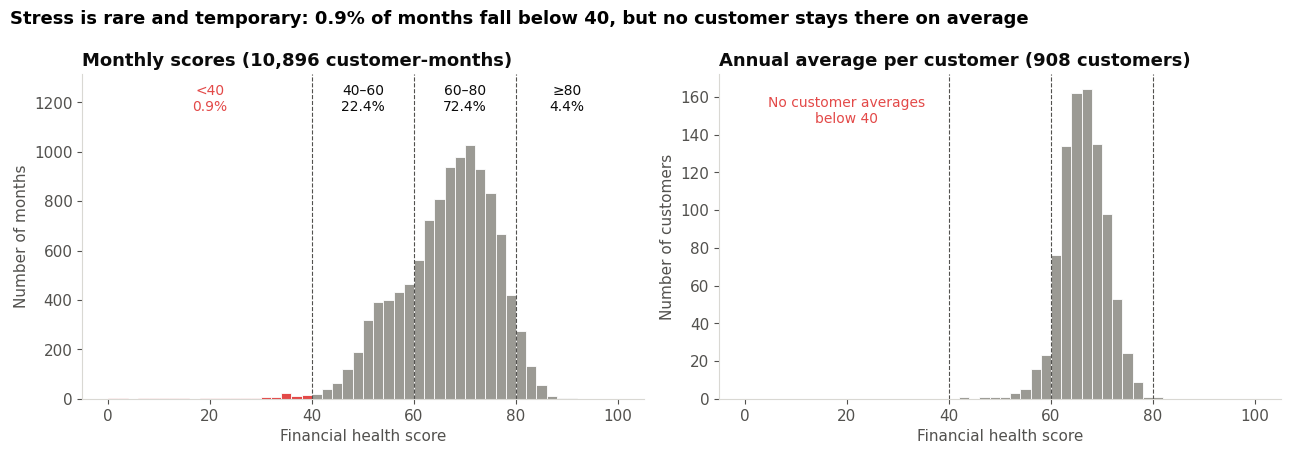

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
bins = np.arange(0, 102, 2)
for ax, data, title, unit in [
    (axes[0], m['financial_health_score'], f'Monthly scores ({len(m):,} customer-months)', 'months'),
    (axes[1], full['health_avg'], f'Annual average per customer ({len(full)} customers)', 'customers')]:
    n, edges, patches = ax.hist(data, bins=bins, color=GRAY, edgecolor='white', linewidth=0.6)
    for p, left in zip(patches, edges[:-1]):
        if left < 40:
            p.set_facecolor(RED)
    for x in (40, 60, 80):
        ax.axvline(x, color=INK2, lw=0.8, ls='--')
    ax.set_title(title)
    ax.set_xlabel('Financial health score')
    ax.set_ylabel(f'Number of {unit}')
    ax.grid(False)
ymax = axes[0].get_ylim()[1] * 1.22
axes[0].set_ylim(0, ymax)
for (lo, hi), b in zip([(0, 40), (40, 60), (60, 80), (80, 100)], BANDS):
    axes[0].text((lo + hi) / 2, ymax * 0.97, f"{b}\n{band_tbl.loc[b, '% tháng']:.1f}%",
                 ha='center', va='top', fontsize=10, color=RED if b == '<40' else INK)
axes[1].text(20, axes[1].get_ylim()[1] * 0.85, 'No customer averages\nbelow 40', ha='center', fontsize=10, color=RED)
fig.suptitle('Stress is rare and temporary: 0.9% of months fall below 40, but no customer stays there on average',
             x=0.01, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout()
save(fig, 's10_health_distribution')

Để thấy rõ "căng thẳng theo tháng" trông như thế nào ở một người cụ thể, tìm trong toàn bộ 10.896 tháng xem **tháng nào có điểm sức khỏe thấp nhất**, rồi lấy khách của tháng đó và xem đủ 12 tháng của người này. Lưu ý đây là người có **một tháng** điểm thấp nhất, không phải người có điểm trung bình năm thấp nhất. Chọn trường hợp cực đoan nhất để thấy rõ nhất một tháng căng thẳng khác các tháng còn lại thế nào.

In [14]:
worst_id = m.loc[m['financial_health_score'].idxmin(), 'consumer_id']
worst_row = m.loc[m['financial_health_score'].idxmin()]
print(f"Tháng có điểm thấp nhất: tháng {worst_row['month']} của khách {worst_id}, điểm {worst_row['financial_health_score']}")
vn(m.loc[m.consumer_id == worst_id, ['month', 'financial_health_score', 'spend_to_income_ratio',
                                  'credit_utilization_ratio', 'essential_spend_ratio', 'engagement_score']] \
 .set_index('month'))

Tháng có điểm thấp nhất: tháng 9 của khách KH00103525, điểm 0.8


,financial_health_score,spend_to_income_ratio,credit_utilization_ratio,essential_spend_ratio,engagement_score
tháng,,,,,
1,75.70,0.41,0.10,0.38,66.00
2,80.60,0.35,0.08,0.63,71.60
3,75.80,0.46,0.11,0.49,68.80
4,60.30,0.81,0.21,0.58,75.20
5,50.60,1.47,0.38,0.45,88.90
6,57.70,0.86,0.21,0.42,74.60
7,71.30,0.62,0.17,0.63,68.90
8,75.70,0.48,0.11,0.67,73.30
9,0.80,6.33,1.50,0.08,64.60


Khách KH00103525 có 11 tháng bình thường, điểm từ 50 đến 80. Riêng tháng 9 điểm rơi xuống 0,8: chi gấp 6,3 lần thu nhập, dùng 150% hạn mức, chi thiết yếu chỉ còn 8%. Sang tháng 10, điểm lên lại 66,3 như chưa có chuyện gì. Một tháng có chuyện đặc biệt, rồi mọi thứ trở lại bình thường.

Từ đây nảy ra ba câu hỏi cho phần 3: chuyện này có phổ biến không, hay chỉ riêng người này? Nó thường rơi vào tháng nào? Và trong tháng đó khách đã chi vào gì?

## Phần 3 – Điểm thấp gắn với những yếu tố nào (slide 10)

**Điểm xuất phát.** Phần 1 đã cho thấy điểm sức khỏe gần như chỉ được tính từ 4 tỷ lệ, trong đó có chi so với thu nhập và hạn mức đã dùng. Trả lời "điểm thấp vì chi nhiều" chỉ là lặp lại cách tính điểm. Phần 2 cho thấy căng thẳng xảy ra trong từng tháng chứ không phải cả năm, như tháng 9 của khách KH00103525. Vì vậy câu hỏi đúng không phải "ai điểm thấp", mà là: **tháng căng thẳng khác tháng bình thường ở chỗ nào?**

Phần này trả lời qua 4 bước. Mỗi bước trả lời một câu hỏi, và câu trả lời mở ra câu hỏi cho bước sau:

1. Tháng căng thẳng khác tháng bình thường ở những chỉ số nào?
2. Căng thẳng có kéo dài sang tháng sau không?
3. Căng thẳng xảy ra vào lúc nào trong năm?
4. Những giao dịch lớn trong tháng căng thẳng là gì?

### Bước 1 – So tháng căng thẳng với tháng bình thường

- **Làm gì:** đặt các tháng dưới 40 cạnh các tháng 60–80, so trung vị của từng chỉ số. Dùng trung vị thay vì trung bình, vì có tháng chi gấp 6 lần thu nhập như ví dụ ở phần 2 sẽ kéo trung bình lệch đi.

In [15]:
drv = m.groupby('band', observed=True)[list(DRIVERS) + ['online_spend_ratio', 'transaction_count',
                                         'average_transaction_value_vnd', 'engagement_score']] \
       .median().round(2)
drv.insert(0, 'số tháng', m['band'].value_counts())
vn(drv).to_csv(OUT / 's11a_drivers_by_band.csv', encoding='utf-8-sig')
vn(drv)

,số tháng,spend_to_income_ratio,credit_utilization_ratio,mức chi thất thường,essential_spend_ratio,online_spend_ratio,transaction_count,average_transaction_value_vnd,engagement_score
mức điểm của tháng,,,,,,,,,
<40,94,1.97,0.56,2.04,0.29,0.32,77.00,"3,444,224.50",81.45
40–60,2436,1.03,0.29,1.87,0.42,0.22,188.00,"1,928,061.00",80.10
60–80,7892,0.58,0.15,1.26,0.50,0.19,152.00,"1,548,453.00",77.80
≥80,474,0.29,0.08,1.00,0.62,0.16,74.00,"1,284,936.50",73.50


- **Thấy gì:** tháng dưới 40 chi gần gấp đôi thu nhập (trung vị 1,97 lần, so với 0,58 lần ở tháng 60–80), dùng 56% hạn mức (so với 15%), chi thiết yếu chỉ 29% (so với 50%). Phần này đúng như dự đoán từ phần 1. Điều lạ là tháng căng thẳng có **ít giao dịch hơn** (77 so với 152) nhưng **mỗi giao dịch lớn gấp khoảng hai lần** (theo trung vị của cột `average_transaction_value_vnd`). Điểm tương tác cũng cao hơn, 81,5 so với 77,8.
- **Suy ra:** tiền không bị tiêu vào nhiều món lặt vặt, mà dồn vào ít giao dịch có giá trị lớn.
- **Câu hỏi tiếp theo:** tình trạng này có kéo dài không, rơi vào lúc nào, và những giao dịch lớn đó là gì? Riêng câu cuối cần mở sổ giao dịch, vì con số trung bình chưa cho biết tiền chia đều cho mọi giao dịch hay dồn vào vài giao dịch rất lớn.

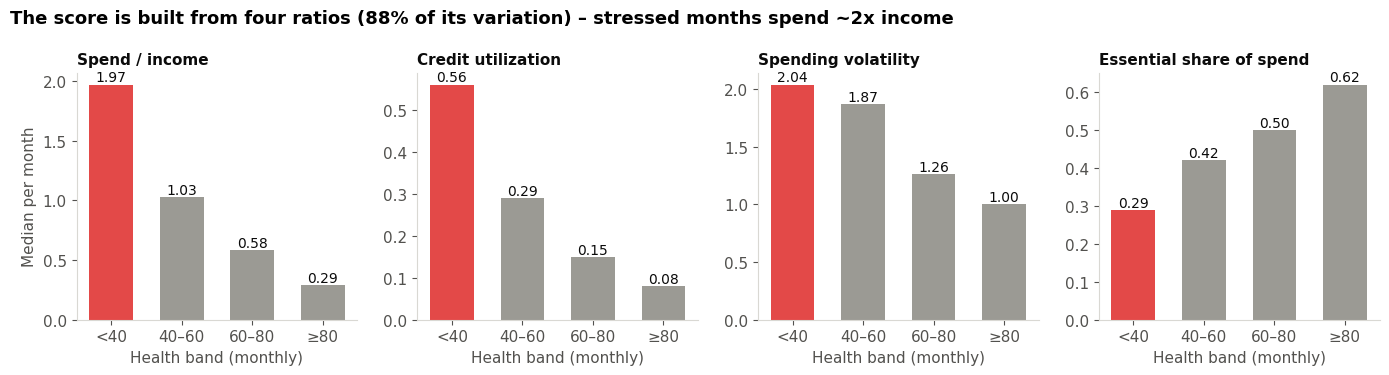

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (col, label) in zip(axes, DRIVERS.items()):
    vals = drv[col]
    ax.bar(BANDS, vals, color=[RED, GRAY, GRAY, GRAY], width=0.62)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=10, color=INK)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Health band (monthly)')
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Median per month')
fig.suptitle(f'The score is built from four ratios ({r2:.0%} of its variation) – stressed months spend ~2x income',
             x=0.01, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout()
save(fig, 's11a_drivers_by_band')

### Bước 2 – Căng thẳng có kéo dài không?

- **Làm gì:** với mỗi tháng, xem điểm của tháng ngay sau đó của cùng khách, rồi đếm xem tháng sau rơi vào mức nào. Tháng 12 không có tháng sau nên không tính.

In [17]:
m = m.sort_values(['consumer_id', 'month']).copy()
m['next_score'] = m.groupby('consumer_id')['financial_health_score'].shift(-1)
pairs = m.dropna(subset=['next_score']).copy()
pairs['next_band'] = to_band(pairs['next_score'])

persist = pairs.groupby('band', observed=True).agg(
    so_thang=('next_score', 'size'),
    pct_thang_sau_van_duoi_40=('next_score', lambda s: round((s < 40).mean() * 100, 1)),
    diem_trung_binh_thang_sau=('next_score', lambda s: round(s.mean(), 1)))
vn(persist).to_csv(OUT / 's11b_persistence.csv', encoding='utf-8-sig')
display(vn(persist))
print('Tỷ lệ % theo dòng: tháng này ở mức nào (dòng) thì tháng sau rơi vào mức nào (cột)')
vn((pd.crosstab(pairs['band'], pairs['next_band'], normalize='index') * 100).round(1))

,số tháng,% trường hợp tháng sau có điểm dưới 40,điểm trung bình tháng sau
mức điểm của tháng,,,
<40,69,4.30,62.30
40–60,1692,1.50,63.00
60–80,7753,0.60,66.20
≥80,474,0.20,72.10


Tỷ lệ % theo dòng: tháng này ở mức nào (dòng) thì tháng sau rơi vào mức nào (cột)


mức tháng sau,<40,40–60,60–80,≥80
mức điểm của tháng,,,,
<40,4.30,37.70,50.70,7.20
40–60,1.50,31.90,65.70,0.90
60–80,0.60,22.70,73.80,3.00
≥80,0.20,9.30,73.80,16.70


- **Thấy gì:** trong 69 tháng dưới 40 có tháng kế tiếp, chỉ 4,3% là tháng sau vẫn dưới 40. Hơn một nửa nhảy thẳng lên mức 60–80, và điểm trung bình của tháng sau là 62,3, gần bằng mức chung. Những trường hợp tháng sau vẫn dưới 40 là ai:

In [18]:
pairs.loc[(pairs.financial_health_score < 40) & (pairs.next_score < 40),
          ['consumer_id', 'month', 'financial_health_score', 'next_score']]

,consumer_id,month,financial_health_score,next_score
3741,KH00106810,1,33.10,30.00
3745,KH00106810,5,7.90,39.50
10483,KH00119085,11,34.20,35.50


Chỉ có 3 lần, thuộc về 2 khách. Để chắc cách tính đúng, đối chiếu với cột `next_month_low_health_flag` có sẵn của đề, cột này đánh dấu tháng sau có dưới 40 hay không:

In [19]:
pd.crosstab(pairs['next_month_low_health_flag'], pairs['next_score'] < 40,
            rownames=['cột của đề'], colnames=['tháng sau < 40 (tự tính)'])

tháng sau < 40 (tự tính),False,True
cột của đề,,
0.00,9915,0
1.00,0,73


Hai cách cho kết quả trùng khớp hoàn toàn.

- **Suy ra:** căng thẳng là một cú sốc ngắn, không phải tình trạng kéo dài.
- **Ý nghĩa cho ITB:** nên hỗ trợ khách **ngay trong tháng đó**, không nên xem họ là khách yếu lâu dài. Đây cũng là thêm một lý do để không dùng điểm sức khỏe cho quyết định tín dụng: điểm của một tháng không nói lên người đó sẽ ra sao ở tháng sau.

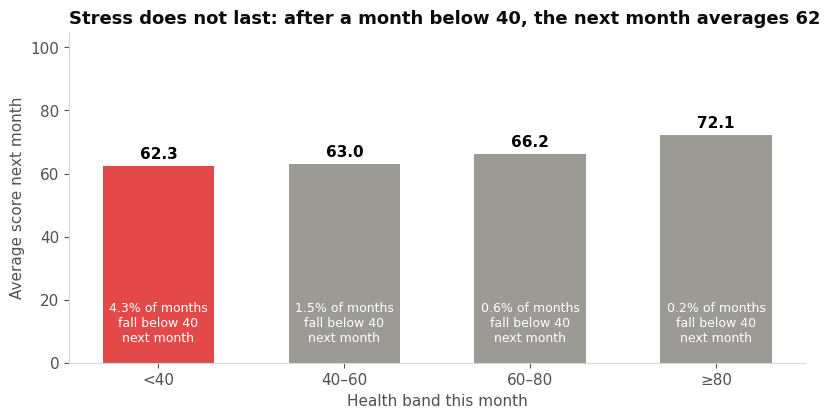

In [20]:
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(persist.index.astype(str), persist['diem_trung_binh_thang_sau'], color=[RED, GRAY, GRAY, GRAY], width=0.6)
for i, (v, p) in enumerate(zip(persist['diem_trung_binh_thang_sau'], persist['pct_thang_sau_van_duoi_40'])):
    ax.text(i, v + 1.5, f'{v:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.text(i, 6, f'{p:.1f}% of months\nfall below 40\nnext month', ha='center', va='bottom', fontsize=9, color='white')
ax.set_ylim(0, 105)
ax.set_ylabel('Average score next month')
ax.set_xlabel('Health band this month')
ax.grid(axis='x', visible=False)
ax.set_title(f"Stress does not last: after a month below 40, the next month averages {persist.loc['<40', 'diem_trung_binh_thang_sau']:.0f}")
save(fig, 's11b_persistence')

### Bước 3 – Căng thẳng xảy ra vào lúc nào?

- **Làm gì:** đếm số lần điểm dưới 40 theo từng tháng trong năm, kèm điểm trung bình và % khách chi vượt thu nhập của mỗi tháng. Mỗi khách chỉ có một điểm cho mỗi tháng, nên số lần dưới 40 trong một tháng cũng chính là số khách dưới 40 trong tháng đó.

In [21]:
season = m.groupby('month').agg(
    so_thang_duoi_40=('financial_health_score', lambda s: (s < 40).sum()),
    diem_trung_binh=('financial_health_score', 'mean'),
    pct_khach_chi_vuot_thu_nhap=('spend_to_income_ratio', lambda s: (s > 1).mean() * 100),
    trung_vi_chi_tren_thu_nhap=('spend_to_income_ratio', 'median')).round(1)
vn(season).rename_axis('tháng').to_csv(OUT / 's11c_seasonality.csv', encoding='utf-8-sig')
dec_jan = season.loc[[12, 1], 'so_thang_duoi_40'].sum()
print(f'Tháng 12 và tháng 1 cộng lại: {dec_jan} trên {season.so_thang_duoi_40.sum()} lần dưới 40')
vn(season).rename_axis('tháng')

Tháng 12 và tháng 1 cộng lại: 46 trên 94 lần dưới 40


,số lần dưới 40,điểm trung bình,% khách chi vượt thu nhập,chi / thu nhập (trung vị)
tháng,,,,
1,21,71.80,2.50,0.40
2,5,73.70,2.00,0.40
3,5,67.30,6.60,0.60
4,6,68.70,5.00,0.60
5,6,67.00,6.50,0.60
6,7,63.30,16.60,0.80
7,6,63.80,13.10,0.70
8,5,63.30,15.90,0.70
9,4,67.80,5.80,0.60


- **Thấy gì:** tháng 12 và tháng 1 chiếm 46 trong 94 lần điểm dưới 40. Tháng 12 nổi bật hẳn: điểm trung bình thấp nhất năm (54,1), khách ở mức giữa chi 1,2 lần thu nhập, và 75,7% khách chi vượt thu nhập, trong khi các tháng khác chỉ từ 2% đến 17%. Mùa hè, từ tháng 6 đến tháng 8, có một đợt tăng nhỏ hơn.

Tháng 1 thì khác: chỉ 2,5% khách chi vượt thu nhập nhưng vẫn có 21 lần dưới 40, tức là một số ít người chi rất mạnh. Kiểm tra xem những người căng thẳng tháng 1 có phải cũng là những người căng thẳng tháng 12 không:

In [22]:
jan = set(m.loc[(m.month == 1) & (m.financial_health_score < 40), 'consumer_id'])
dec = set(m.loc[(m.month == 12) & (m.financial_health_score < 40), 'consumer_id'])
pd.Series({'Khách dưới 40 trong tháng 1': len(jan), 'Khách dưới 40 trong tháng 12': len(dec),
           'Có mặt ở cả hai tháng': len(jan & dec)}).to_frame('số khách')

,số khách
Khách dưới 40 trong tháng 1,21
Khách dưới 40 trong tháng 12,25
Có mặt ở cả hai tháng,2


Chỉ 2 người trùng nhau, nên đây là hai nhóm người khác nhau, không phải một đợt căng thẳng kéo dài qua năm mới.

- **Suy ra:** căng thẳng có **tính mùa vụ**, dồn vào dịp cuối năm và đầu năm, trùng với mua sắm cuối năm và chuẩn bị Tết. Dữ liệu chỉ có một năm 2025, nên chưa khẳng định được năm nào cũng lặp lại đúng như vậy.
- **Ý nghĩa cho ITB:** có thể nhắc khách lập kế hoạch chi tiêu từ tháng 11, trước khi mùa cao điểm bắt đầu.

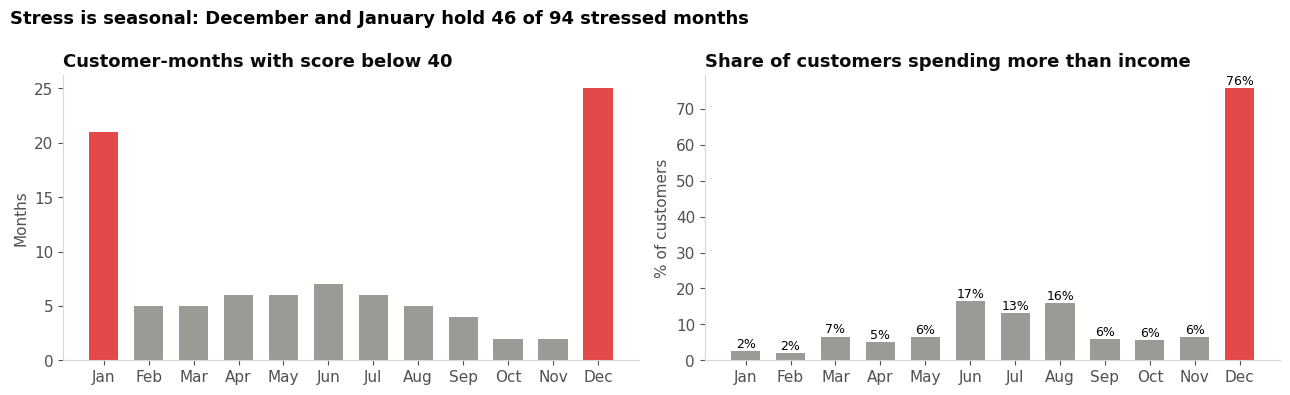

In [23]:
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(MONTHS, season['so_thang_duoi_40'], color=[RED if mo in (12, 1) else GRAY for mo in season.index], width=0.65)
axes[0].set_title('Customer-months with score below 40')
axes[0].set_ylabel('Months')
axes[1].bar(MONTHS, season['pct_khach_chi_vuot_thu_nhap'], color=[RED if mo == 12 else GRAY for mo in season.index], width=0.65)
for i, v in enumerate(season['pct_khach_chi_vuot_thu_nhap']):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
axes[1].set_title('Share of customers spending more than income')
axes[1].set_ylabel('% of customers')
for ax in axes:
    ax.grid(axis='x', visible=False)
fig.suptitle(f'Stress is seasonal: December and January hold {dec_jan} of {season.so_thang_duoi_40.sum()} stressed months',
             x=0.01, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout()
save(fig, 's11c_seasonality')

### Bước 4 – Những giao dịch lớn đó là gì?

- **Làm gì:** file tổng kết theo tháng chỉ có con số tổng, nên phải mở sổ giao dịch, đúng như đề gợi ý. Gắn mức điểm của tháng vào từng giao dịch. Bắt đầu từ một ví dụ cụ thể là tháng 9 của khách KH00103525, rồi kiểm tra xem ví dụ đó có phải kiểu chung của mọi tháng căng thẳng không, theo 3 góc: độ lớn từng giao dịch, chi vào nhóm hàng nào, và chi vào lúc nào.

In [24]:
tx = pd.read_csv(DATA / 'consumer_transactions_2025.csv',
                 usecols=['consumer_id', 'activity_datetime', 'transaction_month', 'spend_amount_vnd',
                          'spending_category', 'merchant_name', 'transaction_channel',
                          'transaction_day_of_week', 'transaction_hour'],
                 dtype={'consumer_id': 'category', 'spending_category': 'category', 'merchant_name': 'category',
                        'transaction_channel': 'category', 'transaction_month': 'int8',
                        'transaction_day_of_week': 'int8', 'transaction_hour': 'int8'})
tx = tx.merge(cm[['consumer_id', 'month', 'band', 'full_year', 'monthly_income_vnd']].rename(columns={'month': 'transaction_month'}),
              on=['consumer_id', 'transaction_month'], how='left')
print('Tổng số giao dịch:', len(tx), '| giao dịch không ghép được với tháng nào:', tx['band'].isna().sum())
# Giao dịch lớn = giao dịch từ 20% thu nhập tháng của chính khách đó trở lên (không dùng mốc VND cố định vì số tiền là giả lập)
tx['big'] = tx['spend_amount_vnd'] >= 0.2 * tx['monthly_income_vnd']
# Trước khi lọc, đếm trên cả 999 khách số người từng có giao dịch lớn, dùng ở phần 6
n_cust_big_all = tx.loc[tx['big'], 'consumer_id'].nunique()
tx = tx[tx.full_year == True].copy()

ex = tx[(tx.consumer_id == worst_id) & (tx.transaction_month == 9)]
print(f'Tháng 9 của {worst_id}: {len(ex)} giao dịch, tổng {ex.spend_amount_vnd.sum() / 1e6:,.1f} triệu')
ex.nlargest(5, 'spend_amount_vnd')[['activity_datetime', 'spending_category', 'merchant_name',
                                    'transaction_channel', 'spend_amount_vnd']]

Tổng số giao dịch: 1852394 | giao dịch không ghép được với tháng nào: 0


Tháng 9 của KH00103525: 67 giao dịch, tổng 737.9 triệu


,activity_datetime,spending_category,merchant_name,transaction_channel,spend_amount_vnd
1215506,2025-09-14 22:19:01.000000,Du lịch,Công ty Du lịch Tân Phát,POS,663603000
1209924,2025-09-13 23:22:30.000000,Giải trí,Trung tâm giải trí Thủ Đô,POS,6511000
1284388,2025-09-29 18:40:05.000000,Ăn uống,Quán Việt Nhật,POS,3374000
1285112,2025-09-29 21:11:02.000000,Ăn uống,Quán Ánh Dương,POS,3340000
1168842,2025-09-04 18:02:50.000000,Ăn uống,Quán ăn Hồng Phúc,Mobile App,3141000


Tháng 9 của người này có 67 giao dịch, tổng 737,9 triệu. Riêng một giao dịch du lịch lúc 22 giờ ngày 14/9 đã là 663,6 triệu, tức 90% chi tiêu cả tháng; các giao dịch còn lại chỉ vài triệu. Một giao dịch duy nhất đã đẩy điểm cả tháng xuống gần 0.

Nhưng một khách chưa đủ để kết luận. Giao dịch trong ví dụ có ba đặc điểm: **rất lớn**, thuộc nhóm **du lịch**, và diễn ra lúc **22 giờ**. Mỗi đặc điểm là một điều cần kiểm tra trên toàn bộ các tháng căng thẳng, tương ứng với ba góc dưới đây: các tháng căng thẳng khác có cũng có một giao dịch lớn so với thu nhập không (góc 1), những giao dịch đó có cũng rơi vào du lịch không (góc 2), và có cũng hay diễn ra vào buổi tối không (góc 3).

**Góc 1 – Độ lớn từng giao dịch.** Số tiền trong dữ liệu là giả lập, nên "giao dịch lớn" không đo bằng một mốc VND cố định mà so với **thu nhập tháng của chính khách đó**: một giao dịch được coi là lớn nếu nó từ **20% thu nhập tháng** trở lên, tức chỉ một lần thanh toán đã bằng một phần năm thu nhập cả tháng. Tính theo hai bước. Trước hết, với từng khách trong từng tháng, tính ba con số:

- **Có giao dịch lớn không:** tháng đó có ít nhất một giao dịch từ 20% thu nhập tháng trở lên hay không.
- **Giao dịch lớn nhất bằng bao nhiêu % thu nhập tháng.**
- **% chi tiêu đến từ các giao dịch lớn:** cộng tiền các giao dịch lớn, chia cho tổng chi tiêu tháng đó.

Với tháng 9 của khách KH00103525:

In [25]:
tx['big_amt'] = tx['spend_amount_vnd'].where(tx['big'], 0)
month_tx = tx.groupby(['consumer_id', 'transaction_month'], observed=True).agg(
    band=('band', 'first'), tong_chi=('spend_amount_vnd', 'sum'), thu_nhap=('monthly_income_vnd', 'first'),
    chi_giao_dich_lon=('big_amt', 'sum'), khoan_lon_nhat=('spend_amount_vnd', 'max'), co_giao_dich_lon=('big', 'any'))
month_tx['lon_nhat_tren_thu_nhap'] = month_tx['khoan_lon_nhat'] / month_tx['thu_nhap'] * 100
month_tx['pct_chi_tu_giao_dich_lon'] = month_tx['chi_giao_dich_lon'] / month_tx['tong_chi'] * 100
# Ví dụ: kết quả bước 1 cho tháng 9 của khách ở phần 2
display(month_tx.loc[(worst_id, 9), ['co_giao_dich_lon', 'lon_nhat_tren_thu_nhap', 'pct_chi_tu_giao_dich_lon']]
        .rename({'co_giao_dich_lon': 'có giao dịch ≥20% thu nhập tháng',
                 'lon_nhat_tren_thu_nhap': 'giao dịch lớn nhất bằng bao nhiêu % thu nhập tháng',
                 'pct_chi_tu_giao_dich_lon': '% chi tiêu đến từ giao dịch lớn'}).to_frame(f'{worst_id}, tháng 9'))

,"KH00103525, tháng 9"
có giao dịch ≥20% thu nhập tháng,True
giao dịch lớn nhất bằng bao nhiêu % thu nhập tháng,569.47
% chi tiêu đến từ giao dịch lớn,89.93


Giao dịch du lịch 663,6 triệu bằng 569% thu nhập tháng của khách, tức gần 5,7 lần thu nhập cả tháng, nên cả ba con số đều rất cao.

Sau đó gộp theo mức điểm: với con số đầu, đếm bao nhiêu % số tháng trả lời "có"; với hai con số sau, lấy trung vị của mọi tháng trong mức.

In [26]:
big_tbl = month_tx.groupby('band', observed=True).agg(
    pct_thang_co_giao_dich_lon=('co_giao_dich_lon', lambda s: s.mean() * 100),
    trung_vi_lon_nhat_tren_thu_nhap=('lon_nhat_tren_thu_nhap', 'median'),
    trung_vi_pct_chi_tu_giao_dich_lon=('pct_chi_tu_giao_dich_lon', 'median')).round(1)
print('Số tháng căng thẳng có giao dịch lớn:', int(month_tx.loc[month_tx.band == '<40', 'co_giao_dich_lon'].sum()),
      'trên', int((month_tx.band == '<40').sum()))
vn(big_tbl).to_csv(OUT / 's11d_big_ticket.csv', encoding='utf-8-sig')
display(vn(big_tbl))
# Thử mốc 10%, 20%, 30% thu nhập tháng: % số tháng có ít nhất một giao dịch vượt mốc
sens_big = {}
for k in (0.10, 0.20, 0.30):
    flag = (tx['spend_amount_vnd'] >= k * tx['monthly_income_vnd']).groupby([tx['consumer_id'], tx['transaction_month']], observed=True).any()
    sens_big[f'mốc {k:.0%} thu nhập'] = flag.groupby(month_tx['band'], observed=True).mean().mul(100).round(1)
pd.DataFrame(sens_big).T.rename_axis('% số tháng có giao dịch vượt mốc')

Số tháng căng thẳng có giao dịch lớn: 69 trên 94


,% số tháng có giao dịch ≥20% thu nhập tháng,giao dịch lớn nhất bằng bao nhiêu % thu nhập tháng (trung vị),% chi tiêu đến từ giao dịch lớn (trung vị)
mức điểm của tháng,,,
<40,73.40,26.90,32.70
40–60,20.60,10.30,0.00
60–80,0.90,3.90,0.00
≥80,0.00,1.90,0.00


band,<40,40–60,60–80,≥80
% số tháng có giao dịch vượt mốc,,,,
mốc 10% thu nhập,96.80,51.40,8.60,0.00
mốc 20% thu nhập,73.40,20.60,0.90,0.00
mốc 30% thu nhập,40.40,9.50,0.10,0.00


- **Thấy gì:**
  - 73,4% số tháng căng thẳng (69 trên 94 tháng) có ít nhất một giao dịch từ 20% thu nhập tháng trở lên. Ở tháng bình thường, tỷ lệ này chỉ là 0,9%; ở tháng khỏe mạnh là 0%.
  - Ở một nửa số tháng căng thẳng, giao dịch lớn nhất bằng từ 26,9% thu nhập tháng trở lên. Ở tháng bình thường, mốc chia đôi này chỉ là 3,9%.
  - Ở một nửa số tháng căng thẳng, từ 32,7% chi tiêu cả tháng đến từ các giao dịch lớn. Ở tháng bình thường, phần lớn các tháng không có giao dịch lớn nào.
  - Đổi mốc sang 10% hoặc 30% thu nhập thì kết quả vẫn cùng chiều (bảng thử mốc ngay trên).
- **Suy ra:** tháng 9 của khách KH00103525 không phải trường hợp lạ. Phần lớn tháng căng thẳng có ít nhất một lần chi lớn so với thu nhập, còn tháng bình thường gần như không có. Căng thẳng thường đến từ một lần chi lớn, không phải từ việc chi nhiều dần đều.

Góc 1 xác nhận căng thẳng thường gắn với một giao dịch lớn so với thu nhập. Câu hỏi tiếp theo là những giao dịch đó thuộc nhóm hàng nào, và giao dịch du lịch trong ví dụ có phải kiểu chung không.

**Góc 2 – Chi vào nhóm hàng nào.** So tỷ trọng chi tiêu theo 14 nhóm chi tiêu giữa các mức điểm.

In [27]:
cat = (tx.groupby(['band', 'spending_category'], observed=True)['spend_amount_vnd'].sum()
         .groupby(level=0, observed=True).transform(lambda s: s / s.sum() * 100).unstack(0).round(1))
cat = cat[BANDS].sort_values('<40', ascending=False)
cat['chênh lệch <40 so với 60–80'] = (cat['<40'] - cat['60–80']).round(1)
vn(cat).to_csv(OUT / 's11d_category_mix.csv', encoding='utf-8-sig')
vn(cat)

mức điểm của tháng,<40,40–60,60–80,≥80,chênh lệch <40 so với 60–80
nhóm chi tiêu,,,,,
Du lịch,23.70,6.60,4.10,1.40,19.60
Mua sắm trực tuyến,15.70,11.60,8.10,4.60,7.60
Siêu thị và tạp hóa tại cửa hàng,11.00,14.40,16.50,19.40,-5.50
Mua sắm tại cửa hàng,10.70,11.70,9.50,5.20,1.20
Dịch vụ trực tuyến khác,7.50,6.20,5.30,3.40,2.20
Xăng dầu và di chuyển,6.00,8.60,9.50,13.20,-3.50
Nhà cửa và tiện ích,4.40,7.10,8.30,10.50,-3.90
Trẻ em và thú cưng,4.20,6.50,7.50,9.30,-3.30
Mua sắm khác tại cửa hàng,3.60,5.50,5.60,3.70,-2.00


- **Thấy gì:** du lịch chiếm 23,7% chi tiêu tháng căng thẳng, gần gấp 6 lần tháng bình thường (4,1%). Mua sắm trực tuyến đứng thứ hai, 15,7% so với 8,1%. Các nhóm thiết yếu như siêu thị, xăng dầu, nhà cửa, trẻ em đều giảm tỷ trọng. Đi từ mức dưới 40 lên mức từ 80, du lịch giảm dần từ 23,7% xuống 1,4%, còn siêu thị tăng dần từ 11,0% lên 19,4%.

Bảng trên xét **toàn bộ chi tiêu** trong tháng, chưa tách riêng các giao dịch lớn. Để trả lời đúng câu hỏi "những giao dịch lớn ở góc 1 thuộc nhóm hàng nào", tính lại tỷ trọng theo nhóm chi tiêu nhưng chỉ xét các giao dịch từ 20% thu nhập tháng trở lên.

In [28]:
big_tx = tx[tx['big']]
print('Số giao dịch từ 20% thu nhập tháng trở lên, theo mức điểm của tháng:')
display(vn(big_tx['band'].value_counts().reindex(BANDS).rename('số giao dịch').to_frame()))
big_cat = (big_tx.groupby(['band', 'spending_category'], observed=True)['spend_amount_vnd'].sum()
             .groupby(level=0, observed=True).transform(lambda s: s / s.sum() * 100).unstack(0).fillna(0).round(1))
big_cat = big_cat[[b for b in BANDS if b in big_cat.columns]].sort_values('<40', ascending=False)
vn(big_cat).to_csv(OUT / 's11d_category_mix_big_transactions.csv', encoding='utf-8-sig')
vn(big_cat)

Số giao dịch từ 20% thu nhập tháng trở lên, theo mức điểm của tháng:


,số giao dịch
mức điểm của tháng,
<40,159
40–60,555
60–80,73
≥80,0


mức điểm của tháng,<40,40–60,60–80
nhóm chi tiêu,,,
Du lịch,65.60,60.20,62.40
Mua sắm trực tuyến,22.10,16.90,14.40
Mua sắm tại cửa hàng,8.50,20.00,14.50
Dịch vụ trực tuyến khác,2.70,1.30,2.80
Mua sắm khác tại cửa hàng,1.10,1.60,5.80


- **Thấy gì:** chỉ xét giao dịch lớn, du lịch chiếm 65,6% số tiền ở tháng căng thẳng, mua sắm trực tuyến 22,1%. Ở tháng 40–60 và 60–80, du lịch cũng chiếm khoảng 60%. Tháng 60–80 chỉ có 73 giao dịch lớn và tháng từ 80 không có giao dịch nào, nên hai cột này chỉ để tham khảo.
- **Suy ra:** giao dịch lớn so với thu nhập hầu như luôn là du lịch, ở mức điểm nào cũng vậy. Điều làm tháng căng thẳng khác biệt là giao dịch lớn **có xuất hiện** (góc 1), và khi xuất hiện thì phần lớn là du lịch. Cộng với bảng toàn bộ chi tiêu phía trên (du lịch 23,7% so với 4,1%), điểm khác biệt thật sự của tháng căng thẳng nằm ở **du lịch**, đúng như ví dụ tháng 9.

Góc 2 xác nhận du lịch là nhóm nổi bật nhất. Còn lại đặc điểm thứ ba của ví dụ: giao dịch diễn ra lúc 22 giờ.

**Góc 3 – Chi vào lúc nào.** So tỷ trọng chi tiêu theo khung giờ trong ngày và ngày trong tuần.

In [29]:
tx['khung_gio'] = pd.cut(tx['transaction_hour'], [0, 6, 12, 18, 24], right=False,
                         labels=['00–06', '06–12', '12–18', '18–24'])
by_hour = (tx.groupby(['band', 'khung_gio'], observed=True)['spend_amount_vnd'].sum()
             .groupby(level=0, observed=True).transform(lambda s: s / s.sum() * 100).unstack().round(1))
by_day = (tx.groupby(['band', 'transaction_day_of_week'], observed=True)['spend_amount_vnd'].sum()
            .groupby(level=0, observed=True).transform(lambda s: s / s.sum() * 100).unstack().round(1))
print('% chi tiêu theo khung giờ')
display(vn(by_hour))
print('% chi tiêu theo ngày trong tuần (mã ngày theo từ điển dữ liệu)')
display(vn(by_day))

% chi tiêu theo khung giờ


khung giờ,00–06,06–12,12–18,18–24
mức điểm của tháng,,,,
<40,16.70,13.70,29.90,39.70
40–60,21.30,19.50,27.30,32.00
60–80,22.30,22.10,27.50,28.10
≥80,25.10,24.70,24.80,25.40


% chi tiêu theo ngày trong tuần (mã ngày theo từ điển dữ liệu)


ngày trong tuần,0,1,2,3,4,5,6
mức điểm của tháng,,,,,,,
<40,21.00,12.50,11.30,9.10,12.70,12.70,20.60
40–60,20.00,15.10,10.70,10.70,11.50,14.10,17.90
60–80,19.30,14.30,10.70,11.00,11.70,14.50,18.60
≥80,18.00,13.90,14.50,11.20,12.40,14.00,16.00


- **Thấy gì:** tháng căng thẳng dồn 39,7% chi tiêu vào khung 18–24 giờ, so với 28,1% ở tháng bình thường; giao dịch du lịch 663,6 triệu ở ví dụ cũng rơi vào lúc 22 giờ. Theo ngày trong tuần thì các mức gần như giống nhau.
- **Suy ra:** ví dụ ban đầu không phải cá biệt. Tháng căng thẳng gắn với **một giao dịch lớn so với thu nhập, không thiết yếu**, chủ yếu là du lịch, hay phát sinh vào buổi tối.
- **Ý nghĩa cho ITB:** ba đặc điểm trên cho biết ITB nên can thiệp ở đâu, lúc nào, và bằng cách gì.
  - **Ở đâu:** không cần theo dõi mọi giao dịch, chỉ cần để ý những giao dịch lớn so với thu nhập của chính khách, nhất là du lịch. Trong tháng căng thẳng, du lịch chiếm 65,6% số tiền của các giao dịch từ 20% thu nhập tháng trở lên.
  - **Lúc nào:** ngay lúc khách thanh toán. Chi tiêu tháng căng thẳng dồn vào buổi tối, nên thông báo cần gửi tức thì, không đợi sao kê cuối tháng.
  - **Bằng cách gì:** khi một giao dịch lớn khiến chi tiêu trong tháng vượt thu nhập, ITB báo cho khách biết mức chi hiện tại, và gợi ý chia giao dịch đó thành nhiều kỳ trả. Bước 2 cho thấy khách thường hồi lại ngay tháng sau, nên chia nhỏ một khoản lớn giúp họ qua tháng khó khăn mà không bị dồn áp lực vào một tháng.
  - Cả ba đều là hỗ trợ, không dùng điểm sức khỏe để từ chối giao dịch hay giảm hạn mức.

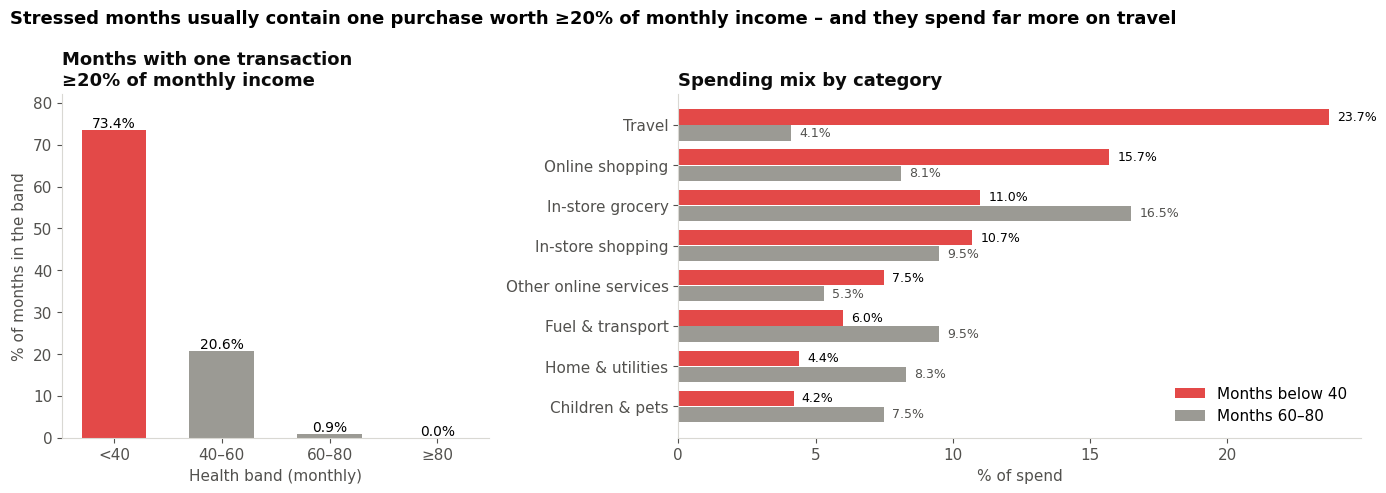

In [30]:
# Tên nhóm chi tiêu tiếng Anh, chỉ dùng cho nhãn biểu đồ (biểu đồ đưa lên slide tiếng Anh)
CAT_EN = {'Du lịch': 'Travel', 'Mua sắm trực tuyến': 'Online shopping',
          'Siêu thị và tạp hóa tại cửa hàng': 'In-store grocery', 'Mua sắm tại cửa hàng': 'In-store shopping',
          'Dịch vụ trực tuyến khác': 'Other online services', 'Xăng dầu và di chuyển': 'Fuel & transport',
          'Nhà cửa và tiện ích': 'Home & utilities', 'Trẻ em và thú cưng': 'Children & pets',
          'Giải trí': 'Entertainment', 'Tạp hóa trực tuyến': 'Online grocery',
          'Mua sắm khác tại cửa hàng': 'Other in-store shopping', 'Ăn uống': 'Food & dining',
          'Chăm sóc cá nhân': 'Personal care', 'Sức khỏe và thể thao': 'Health & fitness'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.6]})
ax = axes[0]
share30 = big_tbl['pct_thang_co_giao_dich_lon']
ax.bar(BANDS, share30, color=[RED, GRAY, GRAY, GRAY], width=0.6)
for i, v in enumerate(share30):
    ax.text(i, v + 0.6, f'{v:.1f}%', ha='center', fontsize=10)
ax.set_title('Months with one transaction\n≥20% of monthly income')
ax.set_ylabel('% of months in the band')
ax.set_xlabel('Health band (monthly)')
ax.grid(axis='x', visible=False)

ax = axes[1]
top = cat.head(8).iloc[::-1]
yy = np.arange(len(top))
ax.barh(yy + 0.2, top['<40'], height=0.38, color=RED, label='Months below 40')
ax.barh(yy - 0.2, top['60–80'], height=0.38, color=GRAY, label='Months 60–80')
for yi, (a, b) in enumerate(zip(top['<40'], top['60–80'])):
    ax.text(a + 0.3, yi + 0.2, f'{a:.1f}%', va='center', fontsize=9)
    ax.text(b + 0.3, yi - 0.2, f'{b:.1f}%', va='center', fontsize=9, color=INK2)
ax.set_yticks(yy, [CAT_EN.get(c, c) for c in top.index])
ax.set_xlabel('% of spend')
ax.set_title('Spending mix by category')
ax.legend(loc='lower right')
ax.grid(axis='y', visible=False)
axes[0].set_ylim(0, share30.max() * 1.12)
fig.suptitle('Stressed months usually contain one purchase worth ≥20% of monthly income – and they spend far more on travel',
             x=0.01, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout()
save(fig, 's11d_what_stressed_months_buy')

### Ghép lại thành kết luận của slide 10

> Căng thẳng tài chính của khách ITB là **cú sốc ngắn**, thường qua ngay tháng sau. Nó **dồn vào dịp cuối năm và đầu năm**, và **gắn với một giao dịch lớn so với thu nhập**, chủ yếu là du lịch.

Mỗi ý dẫn tới một việc ITB làm được: hỗ trợ đúng lúc khách căng thẳng, nhắc lập kế hoạch trước mùa cao điểm, và cảnh báo khi có giao dịch lớn. Khi đưa lên slide, dùng chữ "gắn với" thay vì "gây ra", vì dữ liệu chỉ cho thấy những điều này đi cùng nhau, chưa chứng minh được cái này dẫn tới cái kia.

## Phần 4 – Căng thẳng rơi vào nhóm khách nào? (slide 11)

Phần 3 đã cho thấy căng thẳng xảy ra như thế nào: thường là một cú sốc ngắn, dồn vào cuối năm và gắn với một giao dịch lớn so với thu nhập. Phần này hỏi tiếp: **chuyện đó xảy ra với ai nhiều hơn?** Đề bài yêu cầu xem theo ba cách chia khách là nghề, tuổi và tỉnh. Cả ba đều đi qua cùng bốn bước dưới đây.

**Bước 1. Đo mỗi nhóm bằng hai con số.**
- *Điểm trung bình năm*: nhóm này bình thường khỏe hay yếu.
- *% khách từng có ít nhất một tháng dưới 40*: nhóm này hay gặp cú sốc đến mức nào. Cần thêm con số này vì phần 2 và 3 cho thấy căng thẳng là chuyện của từng tháng. Một nhóm có điểm trung bình khá vẫn có thể có nhiều người từng rơi xuống dưới 40.

**Bước 2. Kiểm tra khác biệt có thật hay chỉ do tình cờ.**
Đặt các nhóm cạnh nhau thì con số nào cũng lệch nhau một chút, và một phần chênh lệch chỉ là tình cờ. Nhóm càng ít người thì càng dễ lệch: chỉ cần một hai khách có năm tệ là điểm trung bình của cả nhóm tụt xuống. Vì vậy, trước khi nói "nhóm A yếu hơn nhóm B", cần kiểm tra bằng hai công cụ:
- *Kiểm định Kruskal-Wallis* trả lời câu "các nhóm có khác nhau không", xét chung tất cả các nhóm. Nếu p < 0,05 thì có khác thật, nhưng kiểm định chưa cho biết nhóm nào khác nhóm nào. Kiểm định này so thứ hạng điểm nên không đòi hỏi điểm phải phân phối chuẩn.
- *Khoảng tin cậy 95%* trên biểu đồ, tính bằng trung bình ± 1,96 × độ lệch chuẩn / √số khách, trả lời tiếp câu "nhóm nào khác nhóm nào, và khác bao nhiêu". Nhóm ít người có gạch dài. Nếu gạch của hai nhóm chồng lên nhau thì chưa đủ căn cứ để nói hai nhóm khác nhau.

**Bước 3. Khác thật rồi, nhưng có đủ lớn để quan tâm không?**
Với 908 khách, một chênh lệch rất nhỏ vẫn có thể "có thật" theo kiểm định. Vì vậy, sau khi biết khác biệt là có thật, vẫn phải nhìn độ lớn của nó: chênh khoảng 1 điểm trên thang 100 thì không đáng đưa lên slide.

**Bước 4. Khác biệt đến từ đâu?**
Chỉ với những khác biệt vừa có thật vừa đủ lớn, mới xem tiếp các tỷ lệ chi tiêu đi kèm trong bảng, như chi tiêu so với thu nhập và tỷ trọng chi thiết yếu. Mục đích là biết nhóm yếu hơn vì chi quá nhiều so với thu nhập hay vì chi vào những khoản khác.

**Cách đọc bảng.** Ba bảng theo nghề, tuổi và tỉnh có cùng các cột. Mỗi dòng là một nhóm khách. Mọi con số được tính theo hai tầng: trước tiên tóm 12 tháng của mỗi khách thành một con số, sau đó gộp các khách trong nhóm lại.

| Cột | Cách tính | Dùng để trả lời |
|---|---|---|
| số khách | Số khách đủ 12 tháng thuộc nhóm | Nhóm lớn hay nhỏ. Nhóm càng nhỏ thì các con số còn lại càng kém chắc chắn |
| điểm trung bình | Điểm sức khỏe trung bình 12 tháng của từng khách, rồi lấy trung bình các khách trong nhóm | Nhóm bình thường khỏe hay yếu (bước 1) |
| % khách từng có tháng dưới 40 | Số khách có ít nhất một tháng dưới 40, chia cho số khách của nhóm | Nhóm hay gặp cú sốc đến mức nào (bước 1) |
| chi / thu nhập | Tỷ lệ chi tiêu so với thu nhập, trung bình 12 tháng của từng khách, rồi lấy trung vị trong nhóm | Khách chi bao nhiêu trên mỗi đồng thu nhập (bước 4) |
| hạn mức đã dùng | Như trên, với tỷ lệ hạn mức tín dụng đã dùng | Khách dựa vào thẻ tín dụng nhiều hay ít (bước 4) |
| tỷ lệ chi thiết yếu | Như trên, với tỷ trọng chi cho nhu cầu thiết yếu | Khách chi vào đâu (bước 4) |
| số tháng chi vượt thu nhập | Số tháng mỗi khách chi nhiều hơn thu nhập, rồi lấy trung bình trong nhóm | Mỗi năm khách tiêu quá thu nhập bao nhiêu tháng (bước 4) |
| khoảng tin cậy 95% (±) | 1,96 × độ lệch chuẩn / √số khách | Điểm trung bình của nhóm chắc chắn đến đâu. Đây là độ dài gạch ngang trên biểu đồ (bước 2) |

Cách so sánh các nhóm: đọc hai cột điểm để biết nhóm nào yếu hơn, rồi đọc cột khoảng tin cậy để biết khác biệt đó có chắc không. Sau đó xem trong bốn cột chi tiêu, cột nào tăng giảm theo điểm. Cột nào thay đổi cùng với điểm thì đó là chỗ tạo ra khác biệt. Cột nào gần như không đổi giữa các nhóm thì không phải nguyên nhân. Ba cột tỷ lệ dùng trung vị thay vì trung bình, để vài khách có tỷ lệ rất cao không kéo lệch cả nhóm.

Cuối phần là một kết luận chung cho cả ba cách chia.

In [31]:
def group_stats(df, col):
    g = df.groupby(col, observed=True)
    out = g.agg(so_khach=('consumer_id', 'size'),
                diem_tb=('health_avg', 'mean'),
                sd=('health_avg', 'std'),
                pct_tung_duoi_40=('months_below_40', lambda s: (s > 0).mean() * 100),
                chi_tren_thu_nhap=('spend_to_income', 'median'),
                han_muc_da_dung=('credit_utilization', 'median'),
                ty_le_thiet_yeu=('essential_ratio', 'median'),
                so_thang_chi_vuot=('months_overspend', 'mean'))
    out['ci95'] = 1.96 * out['sd'] / np.sqrt(out['so_khach'])
    p = stats.kruskal(*[grp['health_avg'].values for _, grp in g]).pvalue
    return out.drop(columns='sd').round(2), p

def fmt_p(p):
    # In đúng giá trị p; p rất nhỏ thì viết dạng khoa học, ví dụ 9.5e-26 = 9,5 × 10^-26
    return f'p = {p:.1e}' if p < 0.001 else f'p = {p:.3f}'

def dot_plot(tbl, title, fname, order=None, muted=None, row_h=0.42, labels=None, highlight=None):
    t = tbl.sort_values('diem_tb') if order is None else tbl.loc[order]
    fig, ax = plt.subplots(figsize=(10, row_h * len(t) + 1.6))
    overall = full['health_avg'].mean()
    ax.axvline(overall, color=INK2, lw=0.8, ls='--')
    ax.text(overall, -0.9, f' All customers: {overall:.1f}', fontsize=9, color=INK2, va='center')
    for yi, (idx, r) in enumerate(t.iterrows()):
        if highlight is not None:
            c = RED if idx in highlight else GRAY
        else:
            c = LGRAY if (muted is not None and muted(r)) else BLUE
        ax.errorbar(r['diem_tb'], yi, xerr=r['ci95'], fmt='o', color=c, ms=7, capsize=0, lw=1.6)
    names = [labels.get(i, i) if labels else i for i in t.index]
    ax.set_yticks(np.arange(len(t)), [f'{nm}  (n={int(n)})' for nm, n in zip(names, t['so_khach'])])
    ax.set_ylim(-1.3, len(t) - 0.5)
    ax.set_xlabel('Average financial health score (annual, per customer)')
    ax.set_title(title)
    ax.grid(axis='y', visible=False)
    fig.tight_layout()
    save(fig, fname)

### Theo lĩnh vực nghề

In [32]:
occ_tbl, p_occ = group_stats(full, 'occupation_group')
vn(occ_tbl).to_csv(OUT / 's12_by_occupation_group.csv', encoding='utf-8-sig')
print('Kiểm định Kruskal-Wallis:', fmt_p(p_occ))
vn(occ_tbl.sort_values('diem_tb'))

Kiểm định Kruskal-Wallis: p = 9.5e-26


,số khách,điểm trung bình,% khách từng có tháng dưới 40,chi / thu nhập,hạn mức đã dùng,tỷ lệ chi thiết yếu,số tháng chi vượt thu nhập,khoảng tin cậy 95% (±)
lĩnh vực nghề,,,,,,,,
"Truyền thông, nghệ thuật và thiết kế",146,63.99,13.70,0.76,0.21,0.50,2.02,0.61
Khu vực công và cộng đồng,58,64.04,8.62,0.81,0.21,0.48,2.29,0.98
Giáo dục,65,64.80,13.85,0.75,0.20,0.50,1.97,0.86
Nông nghiệp và môi trường,41,65.75,2.44,0.71,0.20,0.47,1.51,1.33
Khoa học và nghiên cứu,98,66.06,9.18,0.70,0.19,0.50,1.68,0.81
Y tế và chăm sóc sức khỏe,155,66.52,7.10,0.71,0.18,0.50,1.54,0.69
Tài chính và pháp lý,86,67.94,4.65,0.65,0.17,0.50,1.34,0.90
Kinh doanh và dịch vụ,79,68.06,6.33,0.66,0.17,0.49,1.34,1.07
Kỹ thuật và xây dựng,146,68.21,3.42,0.60,0.17,0.50,1.26,0.64


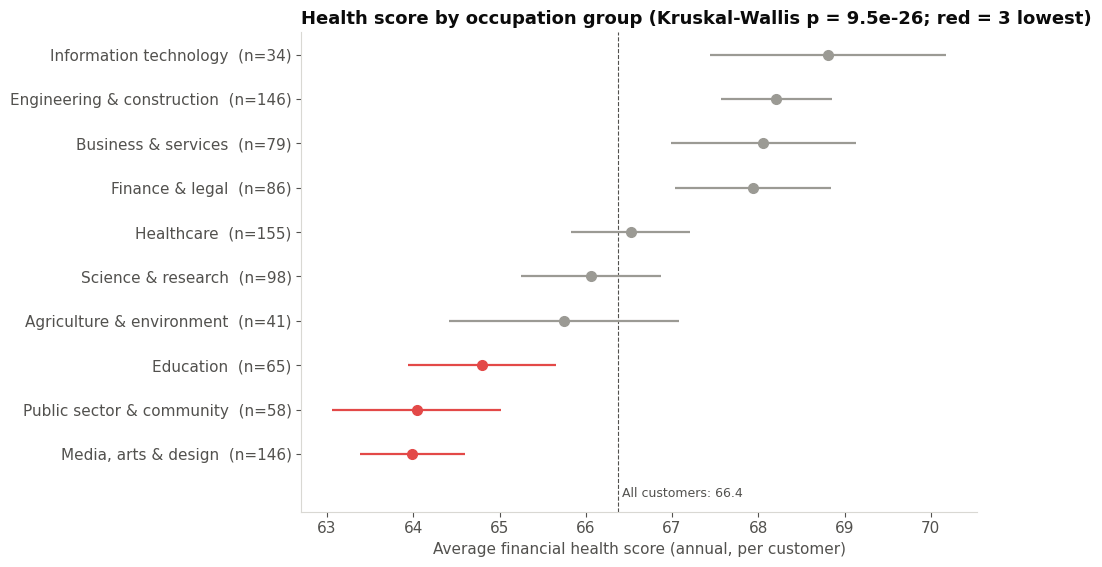

In [33]:
# Tên nghề tiếng Anh, chỉ dùng cho nhãn biểu đồ; tô đỏ 3 nghề điểm thấp nhất
OCC_EN = {'Truyền thông, nghệ thuật và thiết kế': 'Media, arts & design', 'Khu vực công và cộng đồng': 'Public sector & community',
          'Giáo dục': 'Education', 'Nông nghiệp và môi trường': 'Agriculture & environment',
          'Khoa học và nghiên cứu': 'Science & research', 'Y tế và chăm sóc sức khỏe': 'Healthcare',
          'Tài chính và pháp lý': 'Finance & legal', 'Kinh doanh và dịch vụ': 'Business & services',
          'Kỹ thuật và xây dựng': 'Engineering & construction', 'Công nghệ thông tin': 'Information technology'}
low3 = occ_tbl.nsmallest(3, 'diem_tb').index
dot_plot(occ_tbl, f'Health score by occupation group (Kruskal-Wallis {fmt_p(p_occ)}; red = 3 lowest)',
         's12a_by_occupation', labels=OCC_EN, highlight=low3)

Kiểm định cho p = 9,5 × 10⁻²⁶, tức gần như bằng 0 và thấp hơn rất nhiều so với mức 0,05, nên các lĩnh vực nghề khác nhau thật. Trên biểu đồ, các nhóm tách thành hai cụm, và khoảng tin cậy của hai cụm không chồng lên nhau. Cụm dưới gồm truyền thông – nghệ thuật, khu vực công và giáo dục, điểm khoảng 64–65, với 9–14% khách từng có tháng dưới 40. Cụm trên gồm công nghệ thông tin, kỹ thuật, kinh doanh và tài chính, điểm khoảng 68–69, chỉ 0–6% khách từng dưới 40. Hai cụm chênh nhau khoảng 4–5 điểm, đủ lớn để đưa lên slide.

Nhìn sang các cột tỷ lệ thì thấy khác biệt đến từ đâu. Cụm điểm thấp chi khoảng 0,75–0,81 lần thu nhập và chi vượt thu nhập khoảng 2 tháng mỗi năm. Cụm điểm cao chỉ chi 0,60–0,66 lần và vượt khoảng 1,3 tháng. Tỷ trọng chi thiết yếu thì gần như bằng nhau. Vậy khác biệt nằm ở mức chi so với thu nhập, không phải ở chuyện chi vào đâu.

### Theo nhóm tuổi

Kiểm định Kruskal-Wallis: p = 0.027


,số khách,điểm trung bình,% khách từng có tháng dưới 40,chi / thu nhập,hạn mức đã dùng,tỷ lệ chi thiết yếu,số tháng chi vượt thu nhập,khoảng tin cậy 95% (±)
nhóm tuổi,,,,,,,,
<25,51,65.96,7.84,0.66,0.16,0.41,1.39,1.03
25–34,177,65.79,9.04,0.74,0.19,0.47,1.75,0.68
35–44,165,66.44,3.03,0.70,0.18,0.46,1.53,0.65
45–54,186,65.98,11.29,0.72,0.19,0.50,1.68,0.66
55–64,147,67.01,5.44,0.69,0.18,0.52,1.61,0.65
65+,182,66.89,8.24,0.69,0.19,0.51,1.58,0.67


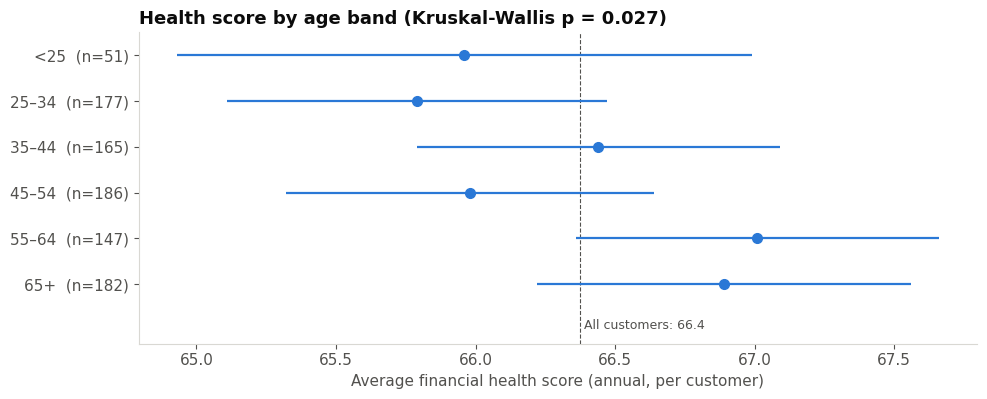

In [34]:
age_tbl, p_age = group_stats(full, 'age_band')
vn(age_tbl).to_csv(OUT / 's12_by_age_band.csv', encoding='utf-8-sig')
print('Kiểm định Kruskal-Wallis:', fmt_p(p_age))
display(vn(age_tbl))
dot_plot(age_tbl, f'Health score by age band (Kruskal-Wallis {fmt_p(p_age)})', 's12b_by_age', order=AGE_LABELS[::-1])

Kiểm định cho p = 0,027, dưới mức 0,05, nên về mặt thống kê các nhóm tuổi có khác nhau. Nhưng trên biểu đồ, khoảng tin cậy của các nhóm chồng lên nhau gần hết. Ngay cả nhóm thấp nhất (25–34 tuổi, 65,8 điểm) và nhóm cao nhất (55–64 tuổi, 67,0 điểm) cũng vẫn chạm nhau, và chỉ chênh 1,2 điểm. Khác biệt có thật nhưng quá nhỏ để có ý nghĩa kinh doanh. Tuổi không phải yếu tố chính của sức khỏe tài chính trong dữ liệu này.

### Theo tỉnh

Kiểm định Kruskal-Wallis: p = 2.5e-05
Số tỉnh có từ 20 khách: 19 trên 34
Kiểm định Kruskal-Wallis chỉ trên các tỉnh có từ 20 khách: p = 0.004


,số khách,điểm trung bình,% khách từng có tháng dưới 40,chi / thu nhập,hạn mức đã dùng,tỷ lệ chi thiết yếu,số tháng chi vượt thu nhập,khoảng tin cậy 95% (±)
tỉnh,,,,,,,,
Hà Tĩnh,9,60.59,22.22,0.88,0.24,0.51,2.78,2.79
Thái Nguyên,17,63.02,17.65,0.81,0.22,0.51,2.47,1.75
Cao Bằng,5,63.14,20.00,0.82,0.24,0.53,2.20,5.66
Đà Nẵng,27,64.15,22.22,0.75,0.21,0.49,2.00,1.32
Điện Biên,8,64.28,0.00,0.75,0.22,0.49,2.38,3.44
Gia Lai,14,64.53,14.29,0.73,0.20,0.53,2.07,2.17
Quảng Trị,12,64.69,0.00,0.81,0.19,0.49,1.92,2.54
Cà Mau,20,64.80,15.00,0.71,0.19,0.48,2.40,2.59
Lâm Đồng,35,64.84,8.57,0.75,0.20,0.50,1.74,2.16


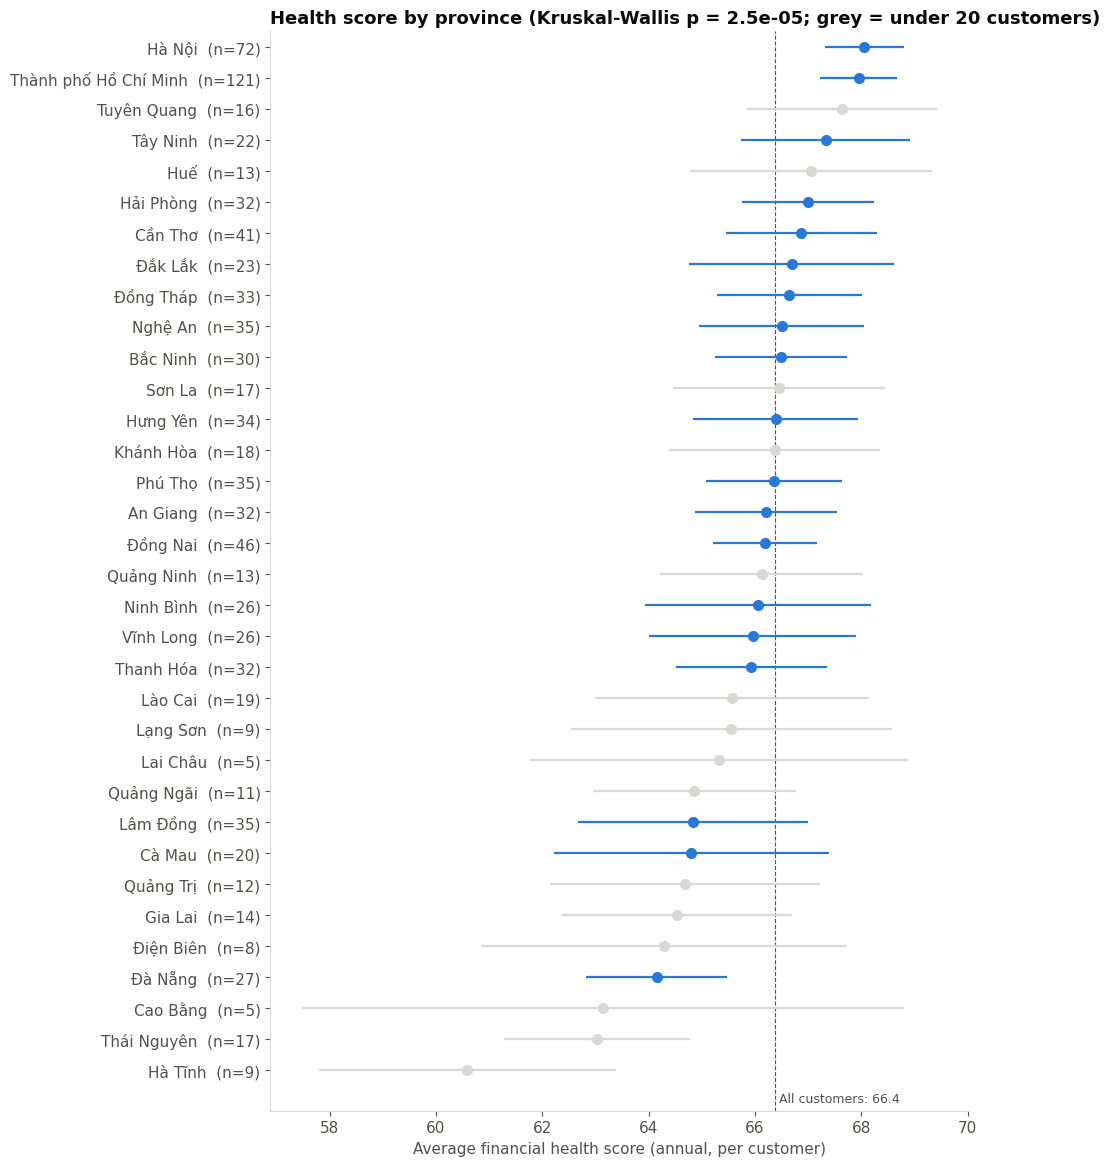

In [35]:
prov_tbl, p_prov = group_stats(full, 'province')
vn(prov_tbl).to_csv(OUT / 's12_by_province.csv', encoding='utf-8-sig')
print('Kiểm định Kruskal-Wallis:', fmt_p(p_prov))
print('Số tỉnh có từ 20 khách:', (prov_tbl.so_khach >= 20).sum(), 'trên', len(prov_tbl))
# Chạy lại kiểm định chỉ trên các tỉnh có từ 20 khách, để chắc kết quả không do tỉnh ít khách
big_prov = prov_tbl.index[prov_tbl.so_khach >= 20]
p_prov20 = stats.kruskal(*[g['health_avg'].values
                           for _, g in full[full.province.isin(big_prov)].groupby('province')]).pvalue
print('Kiểm định Kruskal-Wallis chỉ trên các tỉnh có từ 20 khách:', fmt_p(p_prov20))
display(vn(prov_tbl.sort_values('diem_tb')))
dot_plot(prov_tbl, f'Health score by province (Kruskal-Wallis {fmt_p(p_prov)}; grey = under 20 customers)',
         's12c_by_province', muted=lambda r: r['so_khach'] < 20, row_h=0.3)

Kiểm định trên cả 34 tỉnh cho p = 2,5 × 10⁻⁵, thấp hơn nhiều so với mức 0,05. Nhưng số khách mỗi tỉnh chênh nhau rất nhiều, từ 5 đến 121 người, và tỉnh ít khách có khoảng tin cậy rộng đến mức gần như không kết luận được gì. Ví dụ Hà Tĩnh chỉ có 9 người, đứng cuối bảng, nhưng khoảng tin cậy trải từ khoảng 58 đến 63. Vì vậy, chạy lại kiểm định chỉ trên 19 tỉnh có từ 20 khách trở lên: p = 0,004, tức khác biệt vẫn có thật.

Trong 19 tỉnh này, Hà Nội (68,1) và TP.HCM (68,0) cao nhất. Đà Nẵng thấp nhất (64,2), với 22% khách từng có tháng dưới 40. Khoảng tin cậy của Hà Nội và Đà Nẵng không chồng lên nhau, chênh khoảng 4 điểm. Các tỉnh còn lại nằm ở giữa và chồng lên nhau nhiều, nên không xếp hạng được. Khác biệt cũng đi kèm mức chi so với thu nhập: Hà Nội 0,62 và TP.HCM 0,65, còn Đà Nẵng 0,75.

Từ điển dữ liệu ghi rõ thông tin tỉnh là giả lập, nên kết quả theo tỉnh chỉ là ý phụ, ý chính vẫn là nghề.

### Ghép lại thành kết luận của slide 11

Ba cách chia cho ba mức kết luận khác nhau. Nghề tách được hai cụm rõ ràng, tuổi gần như không, còn tỉnh chỉ tách được vài tỉnh đông khách. Vậy nghề là cách chia đáng dùng. Để thấy nó quan trọng cỡ nào, gộp ba nghề điểm thấp lại và xem họ chiếm bao nhiêu trong số khách từng căng thẳng:

In [36]:
LOW_OCC = ['Truyền thông, nghệ thuật và thiết kế', 'Khu vực công và cộng đồng', 'Giáo dục']
is_low = full['occupation_group'].isin(LOW_OCC)
ever40 = full['months_below_40'] > 0
n_low, n_rest, n_ever = is_low.sum(), (~is_low).sum(), ever40.sum()
n_low_ever, n_rest_ever = (is_low & ever40).sum(), (~is_low & ever40).sum()
pd.Series({
    'Số khách thuộc 3 nghề điểm thấp': f'{n_low / len(full):.1%} ({n_low} / {len(full)})',
    'Số khách từng dưới 40 thuộc 3 nghề này': f'{n_low_ever / n_ever:.1%} ({n_low_ever} / {n_ever})',
    '% khách từng dưới 40 trong 3 nghề này': f'{n_low_ever / n_low:.1%} ({n_low_ever} / {n_low})',
    '% khách từng dưới 40 ở 7 nghề còn lại': f'{n_rest_ever / n_rest:.1%} ({n_rest_ever} / {n_rest})',
}).to_frame('giá trị')

,giá trị
Số khách thuộc 3 nghề điểm thấp,29.6% (269 / 908)
Số khách từng dưới 40 thuộc 3 nghề này,49.3% (34 / 69)
% khách từng dưới 40 trong 3 nghề này,12.6% (34 / 269)
% khách từng dưới 40 ở 7 nghề còn lại,5.5% (35 / 639)


Ba nghề truyền thông – nghệ thuật, khu vực công và giáo dục chỉ chiếm 29,6% trong 908 khách, nhưng chiếm tới 49,3% trong 69 khách từng có tháng dưới 40. Nói cách khác, cứ hai người từng căng thẳng thì gần một người thuộc ba nghề này. Tính trong từng nhóm, 12,6% khách của ba nghề này từng rơi xuống dưới 40 (34 trên 269 người), còn ở bảy nghề còn lại chỉ là 5,5% (35 trên 639 người), chưa bằng một nửa.

Bảng đầu phần 4 cho thấy ba nghề này chi sát thu nhập hơn các nghề khác. Câu hỏi là vì thu nhập thấp hơn hay vì chi nhiều hơn. Số tiền trong dữ liệu là giả lập nên không so trực tiếp bằng VND. Thay vào đó dùng **bách phân vị**: với mỗi khách, tính xem thu nhập trung bình 12 tháng của họ cao hơn bao nhiêu % trong 908 khách, rồi làm tương tự với chi tiêu. Bách phân vị 50 là đứng giữa, 80 là cao hơn 80% số khách. Con số này chỉ cho biết cao hay thấp so với người khác, không nói tốt hay xấu. Sau đó lấy trung vị bách phân vị trong mỗi nhóm:

In [37]:
# Bách phân vị thu nhập và chi tiêu của từng khách trên 908 khách (0–100), dùng lại ở phần 5.
# Dùng bách phân vị thay vì số tiền vì số tiền là giả lập; đề yêu cầu so giữa các khách bằng tỷ lệ.
inc_m = m.groupby('consumer_id', observed=True).agg(thu_nhap=('monthly_income_vnd', 'mean'),
                                                    chi_tieu=('total_spend_vnd', 'mean'))
inc_m['bpv_thu_nhap'] = inc_m['thu_nhap'].rank(pct=True) * 100
inc_m['bpv_chi_tieu'] = inc_m['chi_tieu'].rank(pct=True) * 100
inc_m = inc_m.join(full.set_index('consumer_id')['occupation_group'], how='inner')
nhom_nghe = inc_m['occupation_group'].isin(LOW_OCC).map({True: '3 nghề điểm thấp', False: '7 nghề còn lại'})
occ_inc = inc_m.groupby(nhom_nghe)[['bpv_thu_nhap', 'bpv_chi_tieu']].median().round(0).T
occ_inc.index = ['bách phân vị thu nhập (trung vị)', 'bách phân vị chi tiêu (trung vị)']
occ_inc.columns.name = None
occ_inc

,3 nghề điểm thấp,7 nghề còn lại
bách phân vị thu nhập (trung vị),44.00,52.00
bách phân vị chi tiêu (trung vị),50.00,50.00


Câu trả lời là thu nhập thấp hơn, không phải chi nhiều hơn. Về chi tiêu, khách điển hình của ba nghề này ở bách phân vị 50, tức đứng đúng giữa, bằng các nghề khác. Nhưng về thu nhập, họ chỉ ở bách phân vị 44, tức thu nhập cao hơn 44% số khách, so với 52 ở các nghề khác. Cùng một mức chi, người thu nhập thấp hơn còn ít khoảng dư hơn, nên chỉ cần thêm một khoản chi lớn là dễ rơi xuống dưới 40.

**Ý nghĩa cho ITB.** Các hỗ trợ rút ra ở phần 3, như nhắc lập kế hoạch trước mùa cao điểm và cảnh báo khi có giao dịch lớn, nên triển khai trước cho ba nhóm nghề này. Làm vậy, ITB chỉ cần nhắm vào chưa tới một phần ba số khách mà đã chạm tới khoảng một nửa số người từng căng thẳng. Vì khoảng dư giữa thu nhập và chi tiêu của họ hẹp hơn, mốc cảnh báo nên tính theo thu nhập của từng khách, không dùng một ngưỡng chung cho mọi người. Nghề và điểm sức khỏe chỉ dùng để chọn ai được hỗ trợ trước, không dùng để giảm hạn mức hay từ chối tín dụng.

Phần 5 xem tiếp một nhóm khách chi sát thu nhập quanh năm. Hai trong ba nghề này xuất hiện lại ở đó, nhưng lý do chi sát thu nhập lại khác.

## Phần 5 – Nhóm căng thẳng nhưng tương tác cao (slide 12)

Đề yêu cầu tự đặt một quy tắc rõ ràng, người khác làm lại được. Có hai điều đã biết từ các phần trước khiến không thể dùng mốc có sẵn. Không ai có điểm sức khỏe trung bình năm dưới 40, như phần 2 đã cho thấy. Và gần như ai cũng có điểm tương tác "cao". Kiểm tra lại điều thứ hai:

In [38]:
(m['engagement_segment'].value_counts(normalize=True) * 100).round(1).rename('% số tháng').to_frame()

,% số tháng
engagement_segment,
Tương tác cao,64.80
Tương tác rất cao,35.10
Tương tác trung bình,0.10


99% số tháng thuộc nhóm tương tác "cao" hoặc "rất cao", nên dùng nhóm có sẵn thì gần như ai cũng lọt vào. Cách còn lại là so các khách với nhau. Quy tắc được chọn: xét trên 908 khách đủ năm, dùng điểm trung bình cả năm, lấy khách **thuộc 25% có điểm sức khỏe thấp nhất và đồng thời thuộc 25% có điểm tương tác cao nhất**. Cả hai mốc đều tính cả điểm nằm đúng trên mốc.

In [39]:
h25, e75 = full['health_avg'].quantile(0.25), full['engagement_avg'].quantile(0.75)
full['stressed_engaged'] = (full['health_avg'] <= h25) & (full['engagement_avg'] >= e75)
grp13 = full[full.stressed_engaged]
pd.Series({'Mốc điểm sức khỏe (25% thấp nhất)': f'≤ {h25:.1f}',
           'Mốc điểm tương tác (25% cao nhất)': f'≥ {e75:.1f}',
           'Số khách thỏa cả hai mốc': len(grp13),
           '% trên 908 khách': f'{len(grp13) / len(full):.1%} ({len(grp13)} / {len(full)})',
           f'Trong {len(grp13)} khách này, số người từng có tháng dưới 40':
               f'{(grp13.months_below_40 > 0).mean():.1%} ({(grp13.months_below_40 > 0).sum()} / {len(grp13)})'}).to_frame('giá trị')

,giá trị
Mốc điểm sức khỏe (25% thấp nhất),≤ 63.5
Mốc điểm tương tác (25% cao nhất),≥ 80.1
Số khách thỏa cả hai mốc,64
% trên 908 khách,7.0% (64 / 908)
"Trong 64 khách này, số người từng có tháng dưới 40",10.9% (7 / 64)


Quy tắc cho ra 64 khách, chiếm 7%. Nhưng chỉ 7 người trong số đó từng có tháng dưới 40. Nghĩa là 64 khách này là những người **chịu áp lực tài chính nhiều nhất so với các khách khác**, chứ phần lớn chưa rơi vào mức căng thẳng theo cách đề chia ở Task 1. Vì vậy chữ "căng thẳng" ở nhóm này mang nghĩa tương đối, so với các khách khác.

Tại sao chọn 25% mà không phải mốc khác? Thử thêm hai mức chặt hơn và lỏng hơn:

In [40]:
rows = []
for q in (0.10, 0.25, 0.33):
    hq, eq = full['health_avg'].quantile(q), full['engagement_avg'].quantile(1 - q)
    sel = (full['health_avg'] <= hq) & (full['engagement_avg'] >= eq)
    rows.append({'mốc': f'{q:.0%}', 'điểm sức khỏe tối đa': round(hq, 1), 'điểm tương tác tối thiểu': round(eq, 1),
                 'số khách': int(sel.sum()), '% trên 908': round(sel.mean() * 100, 1),
                 'từng có tháng dưới 40': int((full.loc[sel, 'months_below_40'] > 0).sum())})
sens = pd.DataFrame(rows).set_index('mốc')
sens.to_csv(OUT / 's13_cutoff_sensitivity.csv', encoding='utf-8-sig')
sens

,điểm sức khỏe tối đa,điểm tương tác tối thiểu,số khách,% trên 908,từng có tháng dưới 40
mốc,,,,,
10%,61.30,81.90,8,0.90,3
25%,63.50,80.10,64,7.00,7
33%,64.40,79.50,114,12.60,8


Mốc 10% chỉ còn 8 khách, quá ít để mô tả hay làm riêng một chương trình. Mốc 33% lên 114 khách, nhưng điểm sức khỏe của nhóm khi đó lên tới 64,4, gần bằng mức trung bình chung 66,4, khó gọi là chịu áp lực. Mốc 25% là mức cân bằng giữa hai đầu.

Giờ xem nhóm 64 khách này là ai, bằng cách so với 844 khách còn lại. Trước hết là cách họ chi tiêu. Phần tỷ trọng du lịch và giao dịch lớn được lấy từ sổ giao dịch, để so với phát hiện ở phần 3.

**Cách đọc bảng.** Mỗi ô được tính qua hai bước. Bước 1 tóm 12 tháng của mỗi khách thành một con số, và phép tính khác nhau tùy dòng:
- *Trung bình 12 tháng*: điểm sức khỏe trung bình năm, điểm tương tác trung bình năm, số giao dịch mỗi tháng, chi / thu nhập, hạn mức đã dùng, mức chi thất thường, tỷ lệ chi thiết yếu, tỷ lệ chi online.
- *Tháng thấp nhất*: điểm của tháng thấp nhất trong năm.
- *Đếm số tháng*: số tháng chi vượt thu nhập, tức số tháng có chi / thu nhập lớn hơn 1.
- *Tỷ trọng trên cả năm*, lấy từ sổ giao dịch: % chi cho du lịch và % chi cho mua sắm online. Ví dụ, % chi cho du lịch = tổng tiền mọi giao dịch du lịch trong 12 tháng ÷ tổng tiền mọi giao dịch trong 12 tháng × 100.

  Không lấy trung bình của 12 tỷ lệ tháng, vì cách đó xem tháng chi ít và tháng chi nhiều nặng như nhau. Ví dụ giả định: một khách có tháng 1 chi 100 triệu, trong đó 90 triệu là du lịch; 11 tháng còn lại mỗi tháng chi 10 triệu, không có du lịch. Trung bình 12 tỷ lệ tháng chỉ ra 7,5% (90% ÷ 12), nghe như khách ít đi du lịch. Tính trên tổng cả năm thì ra 42,9% (90 triệu ÷ 210 triệu), đúng với thực tế là gần một nửa số tiền cả năm của khách này dành cho du lịch.

Bước 2 gộp các khách trong nhóm bằng *trung vị*, vì nhóm chỉ có 64 người và vài khách lệch hẳn có thể kéo trung bình đi. Riêng hai dòng % nữ và % khách từng có giao dịch ≥20% thu nhập tháng là số khách thỏa điều kiện chia cho số khách của nhóm. Vì bước 2 dùng trung vị, điểm sức khỏe ở bảng này không so trực tiếp được với điểm trung bình ở các bảng phần 4.

In [41]:
tx['travel_amt'] = tx['spend_amount_vnd'].where(tx['spending_category'] == 'Du lịch', 0)
tx['online_amt'] = tx['spend_amount_vnd'].where(tx['spending_category'] == 'Mua sắm trực tuyến', 0)
per_cust = tx.groupby('consumer_id', observed=True)[['spend_amount_vnd', 'travel_amt', 'online_amt']].sum()
full = full.merge((per_cust[['travel_amt', 'online_amt']].div(per_cust['spend_amount_vnd'], axis=0) * 100)
                  .rename(columns={'travel_amt': 'travel_share', 'online_amt': 'online_shopping_share'}),
                  left_on='consumer_id', right_index=True, how='left')
full['tung_co_giao_dich_lon'] = full['consumer_id'].isin(tx.loc[tx['big'], 'consumer_id'])
grp13 = full[full.stressed_engaged]

PROFILE = ['age', 'health_avg', 'health_min', 'engagement_avg', 'txn_per_month', 'spend_to_income',
           'credit_utilization', 'months_overspend', 'spending_volatility', 'essential_ratio', 'online_ratio',
           'travel_share', 'online_shopping_share']
profile = full.groupby('stressed_engaged')[PROFILE].median().T.round(2)
profile.columns = [f'844 khách còn lại', f'{len(grp13)} khách của nhóm']
profile.loc['pct_tung_co_giao_dich_lon'] = full.groupby('stressed_engaged')['tung_co_giao_dich_lon'].apply(lambda s: round(s.mean() * 100, 1)).values
profile.loc['pct_nu'] = full.groupby('stressed_engaged')['gender'].apply(lambda s: round((s == 'Nữ').mean() * 100, 1)).values
vn(profile).to_csv(OUT / 's13_group_profile.csv', encoding='utf-8-sig')
vn(profile)

,844 khách còn lại,64 khách của nhóm
tuổi,49.00,37.50
điểm sức khỏe trung bình năm,66.76,61.92
điểm của tháng thấp nhất trong năm,51.70,49.05
điểm tương tác trung bình năm,78.25,81.56
số giao dịch mỗi tháng,182.17,243.75
chi / thu nhập,0.69,0.83
hạn mức đã dùng,0.18,0.23
số tháng chi vượt thu nhập,1.00,3.00
mức chi thất thường,1.51,1.83
tỷ lệ chi thiết yếu,0.50,0.47


In [42]:
# Điểm trung bình năm của các khách sát nhau đến mức nào
spread = full[['health_avg', 'engagement_avg']].describe(percentiles=[.25, .5, .75]).loc[['25%', '50%', '75%', 'std']].T.round(1)
spread.columns = ['mốc 25%', 'trung vị', 'mốc 75%', 'độ lệch chuẩn']
display(vn(spread))
con_lai = full[~full.stressed_engaged]
print(f'Trong {len(con_lai)} khách còn lại:')
print(f'  điểm sức khỏe cũng ≤ {h25:.1f} nhưng tương tác không cao: {(con_lai.health_avg <= h25).sum()} người')
print(f'  điểm tương tác cũng ≥ {e75:.1f} nhưng sức khỏe không thấp: {(con_lai.engagement_avg >= e75).sum()} người')

,mốc 25%,trung vị,mốc 75%,độ lệch chuẩn
điểm sức khỏe trung bình năm,63.50,66.30,69.20,4.40
điểm tương tác trung bình năm,76.20,78.60,80.10,3.10


Trong 844 khách còn lại:
  điểm sức khỏe cũng ≤ 63.5 nhưng tương tác không cao: 163 người
  điểm tương tác cũng ≥ 80.1 nhưng sức khỏe không thấp: 163 người


Hai dòng điểm sức khỏe trung bình năm và điểm tương tác trung bình năm chênh nhau là đương nhiên, vì 64 khách được chọn theo đúng hai điều kiện này. Khoảng chênh trông không lớn (4,8 và 3,3 điểm) vì điểm trung bình năm của các khách vốn rất sát nhau: một nửa số khách nằm trong khoảng 63,5–69,2 điểm sức khỏe và 76,2–80,1 điểm tương tác. Ngoài ra, 844 khách còn lại cũng gồm những người chỉ đạt một trong hai điều kiện. Các dòng còn lại mới cho biết nhóm khác ở đâu.

Nhóm 64 khách căng thẳng nhưng tương tác cao trẻ hơn hẳn 844 khách còn lại, tuổi trung vị 37,5 so với 49. Họ dùng thẻ nhiều hơn rõ rệt, 244 giao dịch mỗi tháng so với 182, và chi sát thu nhập hơn, 0,83 so với 0,69 lần thu nhập. Mỗi năm họ có 3 tháng chi vượt thu nhập, trong khi khách khác chỉ có 1 tháng. Họ cũng dùng nhiều hạn mức hơn, 23% so với 18%.

Điểm sức khỏe trung bình năm của 64 khách này thấp hơn gần 5 điểm, nhưng điểm của tháng thấp nhất chỉ thấp hơn chưa tới 3 điểm (49,05 so với 51,70). Điều này cho thấy điểm của họ thấp chủ yếu vì thấp hơn đều qua các tháng, không phải vì một tháng tụt sâu.

Du lịch chỉ chiếm 1,2% chi tiêu của họ, thấp hơn cả khách khác. Tỷ lệ khách từng có ít nhất một giao dịch từ 20% thu nhập tháng trở lên cũng ngang nhau, 43,8% so với 41,7%. Vậy áp lực của 64 khách này **không đến từ cú sốc một giao dịch lớn** như ở phần 3, mà đến từ việc chi nhiều và sát thu nhập quanh năm. Đây là một kiểu áp lực khác hẳn. Xem thêm họ thuộc nghề và độ tuổi nào:

In [43]:
comp_occ = pd.DataFrame({'% trong nhóm': grp13['occupation_group'].value_counts(normalize=True) * 100,
                         '% trên 908 khách': full['occupation_group'].value_counts(normalize=True) * 100}) \
             .round(1).sort_values('% trong nhóm', ascending=False)
comp_age = pd.DataFrame({'% trong nhóm': grp13['age_band'].value_counts(normalize=True) * 100,
                         '% trên 908 khách': full['age_band'].value_counts(normalize=True) * 100}).round(1).sort_index()
display(comp_occ)
comp_age

,% trong nhóm,% trên 908 khách
occupation_group,,
"Truyền thông, nghệ thuật và thiết kế",25.00,16.10
Giáo dục,17.20,7.20
Y tế và chăm sóc sức khỏe,17.20,17.10
Khoa học và nghiên cứu,9.40,10.80
Khu vực công và cộng đồng,9.40,6.40
Kỹ thuật và xây dựng,7.80,16.10
Kinh doanh và dịch vụ,6.20,8.70
Nông nghiệp và môi trường,4.70,4.50
Công nghệ thông tin,1.60,3.70


,% trong nhóm,% trên 908 khách
age_band,,
<25,14.10,5.60
25–34,25.00,19.50
35–44,26.60,18.20
45–54,26.60,20.50
55–64,3.10,16.20
65+,4.70,20.00


64 khách căng thẳng nhưng tương tác cao gần như đều đang trong tuổi đi làm. Hai nhóm tuổi từ 55 trở lên gần như vắng mặt (3,1% và 4,7%), trong khi trên 908 khách họ chiếm 16,2% và 20,0%. Ngược lại, người dưới 25 tuổi chiếm 14,1%, gấp hơn hai lần tỷ lệ 5,6% trên 908 khách. Về nghề, nhóm nghiêng hẳn về truyền thông – nghệ thuật (25,0% so với 16,1%) và giáo dục (17,2% so với 7,2%), còn kỹ thuật và tài chính – pháp lý thì thưa hẳn. Truyền thông – nghệ thuật và giáo dục cũng nằm trong ba nghề điểm thấp ở phần 4, nên hai cách tiếp cận, một bên chia theo nghề, một bên lọc theo điểm, có phần trùng nhau.

Ở phần 4, ba nghề điểm thấp chi sát thu nhập vì thu nhập thấp hơn. Với 64 khách này thì sao:

In [44]:
inc5 = inc_m.join(full.set_index('consumer_id')['stressed_engaged'], how='inner')
inc_tbl = inc5.groupby('stressed_engaged')[['bpv_thu_nhap', 'bpv_chi_tieu']].median().round(0).T
inc_tbl.columns = [f'{len(full) - len(grp13)} khách còn lại', f'{len(grp13)} khách của nhóm']
inc_tbl.index = ['bách phân vị thu nhập (trung vị)', 'bách phân vị chi tiêu (trung vị)']
inc_tbl

,844 khách còn lại,64 khách của nhóm
bách phân vị thu nhập (trung vị),49.00,62.00
bách phân vị chi tiêu (trung vị),48.00,79.00


Ngược lại với phần 4. Về thu nhập, khách điển hình của 64 khách này ở bách phân vị 62, cao hơn 844 khách còn lại (49). Về chi tiêu, họ ở bách phân vị 79, tức chi nhiều hơn 79% số khách, trong khi nhóm còn lại ở 48. Vậy áp lực của 64 khách này nằm ở mức chi, không ở thu nhập. Cùng là chi sát thu nhập, nhưng ba nghề ở phần 4 là do thu nhập thấp, còn 64 khách này là do chi nhiều.

Điều này quyết định cách hỗ trợ. Thứ 64 khách này cần là công cụ giúp nhìn và kiểm soát mức chi, như lập ngân sách hay nhắc khi chi tiêu trong tháng sắp chạm thu nhập, chứ không phải thêm hạn mức hay khoản vay. Và vì đây là nhóm tương tác cao nhất, một công cụ đặt trong app của ITB có nhiều khả năng đến được tay họ.

Vài khách cụ thể trong 64 khách này, để thấy họ trông như thế nào:

In [45]:
vn(grp13.sort_values('health_avg')[['consumer_id', 'age', 'occupation', 'province', 'health_avg', 'health_min',
                                 'engagement_avg', 'txn_per_month', 'months_overspend']].head(5))

,mã khách,tuổi,nghề,tỉnh,điểm sức khỏe trung bình năm,điểm của tháng thấp nhất trong năm,điểm tương tác trung bình năm,số giao dịch mỗi tháng,số tháng chi vượt thu nhập
609,KH00112205,46,Nhân viên pha chế cà phê,Nghệ An,50.82,27.80,82.42,182.75,5
782,KH00115650,45,Cán bộ giáo dục môi trường,Hà Tĩnh,52.28,13.10,82.24,122.58,3
136,KH00102730,35,Nhân viên cấp cứu,Cà Mau,55.74,24.40,83.09,304.17,6
592,KH00111850,43,Thư ký công ty,Hưng Yên,56.71,36.20,80.66,122.25,4
508,KH00110170,34,Trợ lý chính trị gia,Đà Nẵng,57.39,36.30,80.15,183.42,5


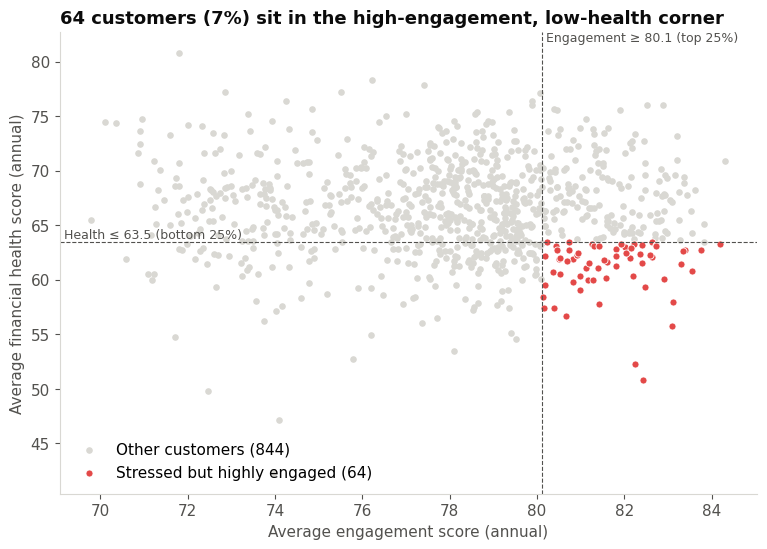

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))
rest = full[~full.stressed_engaged]
ax.scatter(rest['engagement_avg'], rest['health_avg'], s=14, color=LGRAY, label=f'Other customers ({len(rest)})')
ax.scatter(grp13['engagement_avg'], grp13['health_avg'], s=26, color=RED, edgecolor='white', linewidth=0.6,
           label=f'Stressed but highly engaged ({len(grp13)})')
ax.axhline(h25, color=INK2, lw=0.8, ls='--')
ax.axvline(e75, color=INK2, lw=0.8, ls='--')
ax.text(ax.get_xlim()[0], h25, f' Health ≤ {h25:.1f} (bottom 25%)', va='bottom', fontsize=9, color=INK2)
ax.text(e75, ax.get_ylim()[1], f' Engagement ≥ {e75:.1f} (top 25%)', va='top', fontsize=9, color=INK2)
ax.set_xlabel('Average engagement score (annual)')
ax.set_ylabel('Average financial health score (annual)')
ax.set_title(f'{len(grp13)} customers ({len(grp13)/len(full):.0%}) sit in the high-engagement, low-health corner')
ax.legend(loc='lower left')
save(fig, 's13_stressed_engaged_scatter')
full.loc[full.stressed_engaged, ['consumer_id', 'age', 'gender', 'occupation', 'occupation_group', 'province',
                                 'health_avg', 'health_min', 'months_below_40', 'engagement_avg']] \
    .to_csv(OUT / 'stressed_engaged_customers.csv', index=False, encoding='utf-8-sig')

## Phần 6 – Tóm tắt và các tín hiệu chuyển sang Task 5

Lưu bảng theo khách đã xử lý, và đếm số khách mà mỗi gợi ý cho Task 5 có thể tiếp cận. Số khách tiếp cận tính trên toàn bộ 999 khách, vì chương trình của ITB áp dụng cho mọi khách chứ không chỉ người đủ năm.

In [47]:
full.to_csv(OUT / 'task2_customer_level.csv', index=False, encoding='utf-8-sig')
reach = pd.Series({
    'Khách từng có ít nhất 1 tháng dưới 40': cm.loc[cm.financial_health_score < 40, 'consumer_id'].nunique(),
    'Khách dưới 40 vào tháng 12 hoặc tháng 1': cm.loc[(cm.financial_health_score < 40) & cm.month.isin([12, 1]), 'consumer_id'].nunique(),
    'Khách chi vượt thu nhập trong tháng 12': cm.loc[(cm.month == 12) & (cm.spend_to_income_ratio > 1), 'consumer_id'].nunique(),
    'Khách có ít nhất 1 tháng chi vượt thu nhập': cm.loc[cm.spend_to_income_ratio > 1, 'consumer_id'].nunique(),
    'Nhóm căng thẳng nhưng tương tác cao (slide 12)': len(grp13),
    'Khách có ít nhất 1 giao dịch từ 20% thu nhập tháng': n_cust_big_all,
}).to_frame('số khách')
reach['% trên 999 khách'] = (reach['số khách'] / cm.consumer_id.nunique() * 100).round(1)
reach

,số khách,% trên 999 khách
Khách từng có ít nhất 1 tháng dưới 40,70,7.00
Khách dưới 40 vào tháng 12 hoặc tháng 1,44,4.40
Khách chi vượt thu nhập trong tháng 12,687,68.80
Khách có ít nhất 1 tháng chi vượt thu nhập,753,75.40
Nhóm căng thẳng nhưng tương tác cao (slide 12),64,6.40
Khách có ít nhất 1 giao dịch từ 20% thu nhập tháng,389,38.90


### Câu chuyện của Task 2

Điểm sức khỏe tài chính gần như chỉ là bản tóm tắt của mức chi so với thu nhập và hạn mức đã dùng. Vì vậy câu chuyện thật nằm ở chỗ khác: căng thẳng xảy ra khi nào, với ai, và vì khách chi vào đâu.

Căng thẳng tài chính ở khách ITB hiếm và ngắn. Chỉ 0,9% số tháng rơi xuống dưới 40, không khách nào dưới 40 tính trung bình cả năm, và 96% trường hợp hồi lại ngay tháng sau. Có hai kiểu áp lực khác nhau, và chúng cần hai cách hỗ trợ khác nhau:

- **Cú sốc ngắn.** Một giao dịch lớn so với thu nhập, chủ yếu là du lịch, hay vào buổi tối, dồn vào tháng 12 và tháng 1. Điển hình là một chuyến du lịch bằng 5,7 lần thu nhập tháng của một khách.
- **Áp lực đều quanh năm.** 64 khách trẻ, dùng thẻ nhiều, thu nhập không thấp nhưng chi nhiều, 3 tháng mỗi năm chi vượt thu nhập. Họ tập trung ở truyền thông – nghệ thuật và giáo dục.

Theo nhóm khách, nghề tạo khác biệt rõ nhất: ba nghề truyền thông – nghệ thuật, khu vực công và giáo dục chiếm 29,6% số khách nhưng chiếm 49,3% số khách từng có tháng dưới 40, vì họ chi tiêu như các nghề khác trong khi thu nhập thấp hơn. Tuổi gần như không khác, còn tỉnh thì bị giới hạn bởi số khách ít và dữ liệu giả lập.

### Các tín hiệu chuyển sang Task 5

Kế hoạch cuối cùng, với nhóm mục tiêu đã chốt, nằm trong notebook Task 5.

Số khách lấy từ bảng ngay trên. Không gợi ý nào dùng điểm sức khỏe để từ chối cho vay, giảm hạn mức hay khóa tài khoản.

- **Cảnh báo chi tiêu.** 73,4% số tháng căng thẳng có ít nhất một giao dịch từ 20% thu nhập tháng trở lên, so với 0,9% ở tháng bình thường (cột `spend_amount_vnd`, `monthly_income_vnd`). Quy tắc cảnh báo cụ thể: báo cho khách ngay khi một giao dịch vượt 20% thu nhập tháng. Đối tượng là 389 khách từng có giao dịch như vậy, ưu tiên trước 70 khách từng có tháng dưới 40.
- **Nhắc lập kế hoạch tài chính.** 46 trong 94 lần căng thẳng rơi vào tháng 12 và tháng 1, và 75,7% khách chi vượt thu nhập trong tháng 12 (cột `analysis_month`, `spend_to_income_ratio`). Đối tượng là 687 khách chi vượt thu nhập trong tháng 12, nhắc từ tháng 11.
- **Công cụ lập ngân sách.** 64 khách áp lực cao nhất chi vượt thu nhập 3 tháng mỗi năm, gấp ba khách khác (cột `spend_to_income_ratio`). Có thể mở rộng ra 753 khách có ít nhất một tháng chi vượt thu nhập.
- **Trả góp cho giao dịch lớn.** Trong tháng căng thẳng, 65,6% số tiền của các giao dịch lớn là du lịch (cột `spending_category`). Khi một giao dịch vượt 20% thu nhập tháng, ITB có thể đề nghị chia thành nhiều kỳ trả để chi phí không dồn vào một tháng. Đây là lựa chọn để khách tự quyết, cần ghi rõ phí trả góp để không biến thành một khoản nợ mới. Đối tượng là 389 khách có ít nhất một giao dịch như vậy.

### Các file tạo ra

- `charts/`: 9 biểu đồ dùng ở slide 9–12.
- `outputs/task2_customer_level.csv`: bảng theo khách đã xử lý.
- `outputs/occupation_groups.csv`: bảng gộp 396 nghề thành 10 lĩnh vực.
- `outputs/stressed_engaged_customers.csv`: danh sách 64 khách ở slide 12.
- Các file `outputs/s10_...` đến `outputs/s13_...`: bảng số của từng phần.